# Thực nghiệm TA-ACRF-RNN
> **TA-ACRF-RNN paper-fair = Corrected ACRF-RNN + Time-aware relation + fixed epoch/threshold**

Quy trình chính:
1. Kiểm tra môi trường, clone repo và chuẩn bị dữ liệu.
2. Tạo `layer_ta_acrf_rnn.py` và `model_ta_acrf_rnn.py`.
3. Ghi đè `main_ta_acrf_rnn.py` theo hướng paper-fair.
4. Tune trên validation year 2017 để lấy `fixed_epoch` và `fixed_threshold`.
5. Test năm 2018, 2019, 2020 bằng cùng `fixed_epoch=40` và `fixed_threshold=0.68`.
6. Tổng hợp kết quả TA-ACRF-RNN và so sánh với paper.


## Giai đoạn 1 — Kiểm tra môi trường và cài thư viện


In [ ]:
!python --version
import torch
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), "GB")
else:
    print("Không có GPU - vào Runtime > Change runtime type > GPU")

!pip install -q numpy pandas scipy scikit-learn tqdm


Python 3.12.13
Torch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4
VRAM: 14.6 GB


## Giai đoạn 2 — Clone repo và tạo thư mục làm việc


In [ ]:
import os
os.chdir("/content")

!rm -rf /content/ACRF-RNN
!git clone https://github.com/XNetLab/ACRF-RNN.git

os.makedirs("/content/project_data", exist_ok=True)
os.makedirs("/content/project_outputs", exist_ok=True)
os.makedirs("/content/ACRF-RNN/Code/savemodel", exist_ok=True)

print("Thư mục sẵn sàng")
!ls /content/ACRF-RNN/Code/


Cloning into 'ACRF-RNN'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 32 (delta 4), reused 32 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 3.45 MiB | 7.54 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Thư mục sẵn sàng
layer.py  main.py  model.py  savemodel	util4.py


## Giai đoạn 3 — Tải và kiểm tra dữ liệu từ Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json

JSON_SRC  = '/content/drive/MyDrive/ACRF-RNN/processed_flat.json'
JSON_DEST = '/content/project_data/processed_flat.json'

!cp "{JSON_SRC}" "{JSON_DEST}"

size_mb = os.path.getsize(JSON_DEST) / 1024**2
with open(JSON_DEST, encoding="utf-8") as f:
    meta = json.load(f)

print(f"File: {JSON_DEST} ({size_mb:.1f} MB)")
print(f"format           : {meta['format']}")
print(f"num_years        : {meta['num_years']}")
print(f"num_companies    : {meta['num_companies_per_year']}")
print(f"num_cols_per_row : {meta['num_columns_per_row']}")
print(f"years            : {[d['year'] for d in meta['data']]}")
print(f"last 3 cols      : {meta['columns'][-3:]}")

assert meta["num_columns_per_row"] == 209, "Số cột sai, kiểm tra lại pipeline"
assert meta["columns"][-1] == "label", "Cột cuối phải là label"
print("File JSON hợp lệ")


Mounted at /content/drive
File: /content/project_data/processed_flat.json (20.5 MB)
format           : main_py_compatible_year_major
num_years        : 10
num_companies    : 491
num_cols_per_row : 209
years            : [2010, 2011, 2012, 2013, 2014, 2015, 2017, 2018, 2019, 2020]
last 3 cols      : ['D000200000', 'sj_label', 'label']
File JSON hợp lệ


## Giai đoạn 3.5 — Khám phá dữ liệu và minh họa data mining

Phần này bổ sung các hình minh họa để notebook có đầy đủ luồng data mining: hiểu dữ liệu, kiểm tra mất cân bằng lớp, quan sát không gian đặc trưng và minh họa quy trình thực nghiệm.

Lưu ý: các mốc thời gian trong biểu đồ được mã hóa thành `T1, T2, ...` để tập trung vào xu hướng dữ liệu, không hiển thị nhãn năm gốc.

In [ ]:
import os, json, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

DATA_PATH = "/content/project_data/processed_flat.json"
FIG_DIR = "/content/project_outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

with open(DATA_PATH, "r", encoding="utf-8") as f:
    payload = json.load(f)

years_raw = [b["year"] for b in payload["data"]]
rows_np = np.array([b["rows"] for b in payload["data"]], dtype=np.float32)

X_all_by_time = rows_np[:, :, :-1]
y_all_by_time = rows_np[:, :, -1].astype(int)

time_alias = [f"T{i+1}" for i in range(len(years_raw))]
alias_map = pd.DataFrame({"time_alias": time_alias, "original_year": years_raw})
alias_map.to_csv("/content/project_outputs/time_alias_mapping_private.csv", index=False)

print(f"Data shape: X={X_all_by_time.shape}, y={y_all_by_time.shape}")
print("Các biểu đồ sẽ dùng nhãn thời gian dạng T1, T2, ... để không hiển thị năm gốc.")

Data shape: X=(10, 491, 208), y=(10, 491)
Các biểu đồ sẽ dùng nhãn thời gian dạng T1, T2, ... để không hiển thị năm gốc.


,time_alias,Benign,Fraud,Total,Fraud_rate
0,T1,386,105,491,0.213849
1,T2,361,130,491,0.264766
2,T3,358,133,491,0.270876
3,T4,375,116,491,0.236253
4,T5,377,114,491,0.232179
5,T6,351,140,491,0.285132
6,T7,369,122,491,0.248473
7,T8,364,127,491,0.258656
8,T9,381,110,491,0.224033
9,T10,405,86,491,0.175153


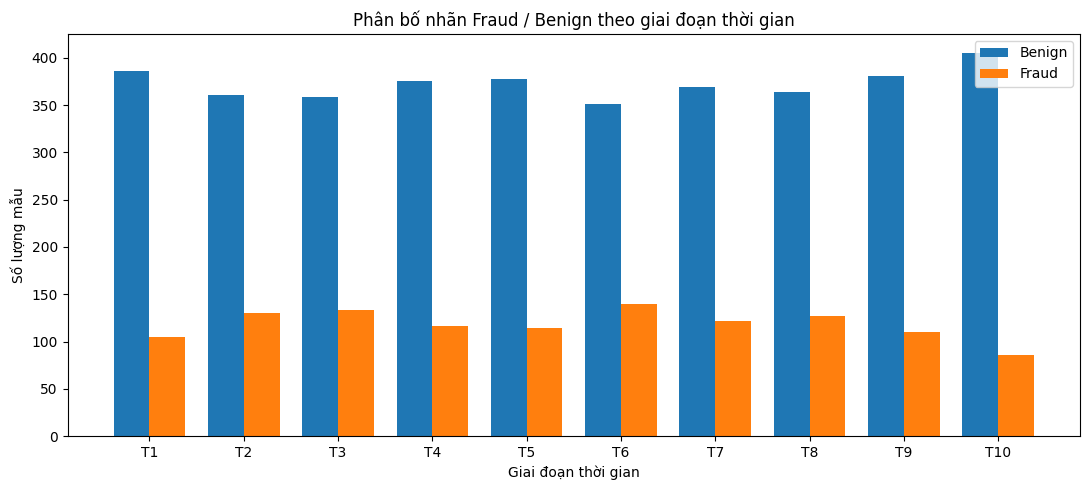

In [ ]:
# 4.1 Phân bố Fraud / Benign theo từng giai đoạn thời gian

label_rows = []
for idx, alias in enumerate(time_alias):
    y_t = y_all_by_time[idx].reshape(-1)
    benign = int(np.sum(y_t == 0))
    fraud = int(np.sum(y_t == 1))
    total = benign + fraud
    label_rows.append({
        "time_alias": alias,
        "Benign": benign,
        "Fraud": fraud,
        "Total": total,
        "Fraud_rate": fraud / total if total else 0.0
    })

label_dist_df = pd.DataFrame(label_rows)
display(label_dist_df)

x_pos = np.arange(len(label_dist_df))
width = 0.38

plt.figure(figsize=(11, 5))
plt.bar(x_pos - width/2, label_dist_df["Benign"], width, label="Benign")
plt.bar(x_pos + width/2, label_dist_df["Fraud"], width, label="Fraud")
plt.xticks(x_pos, label_dist_df["time_alias"])
plt.xlabel("Giai đoạn thời gian")
plt.ylabel("Số lượng mẫu")
plt.title("Phân bố nhãn Fraud / Benign theo giai đoạn thời gian")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_label_distribution_by_time.png", dpi=200)
plt.show()

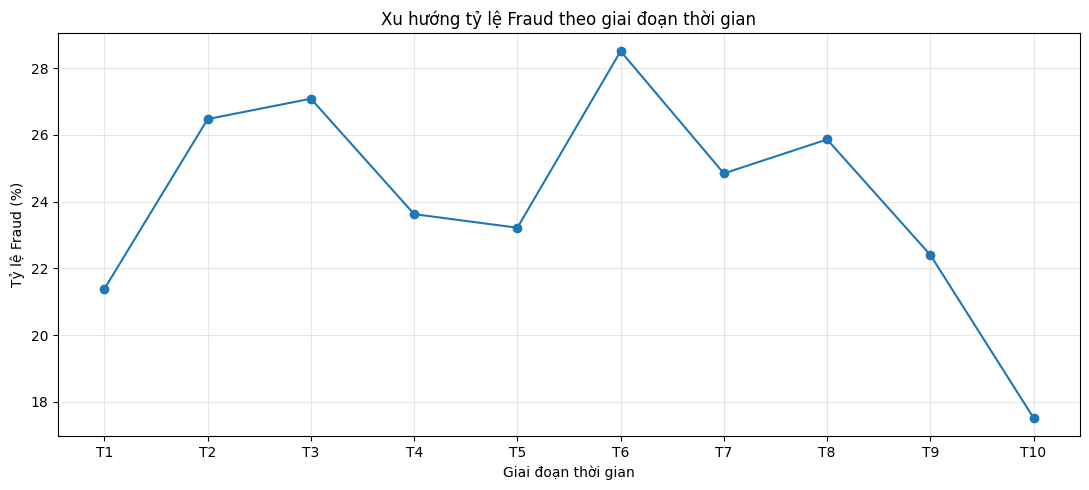

In [ ]:
# 4.2 Tỷ lệ Fraud theo giai đoạn thời gian

plt.figure(figsize=(11, 5))
plt.plot(label_dist_df["time_alias"], label_dist_df["Fraud_rate"] * 100, marker="o")
plt.xlabel("Giai đoạn thời gian")
plt.ylabel("Tỷ lệ Fraud (%)")
plt.title("Xu hướng tỷ lệ Fraud theo giai đoạn thời gian")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_fraud_rate_trend.png", dpi=200)
plt.show()

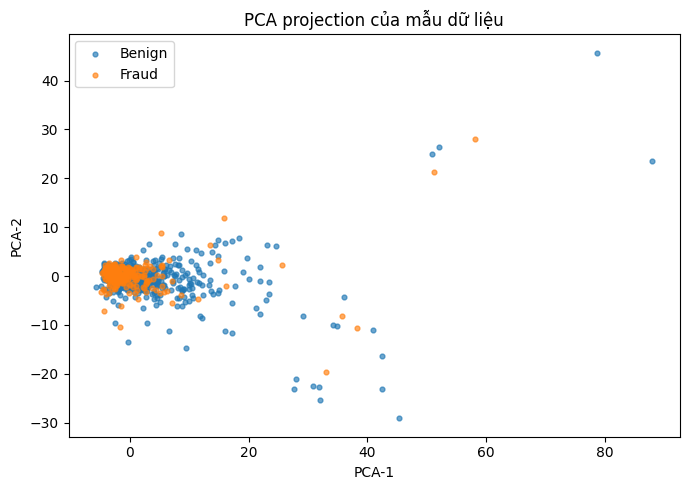

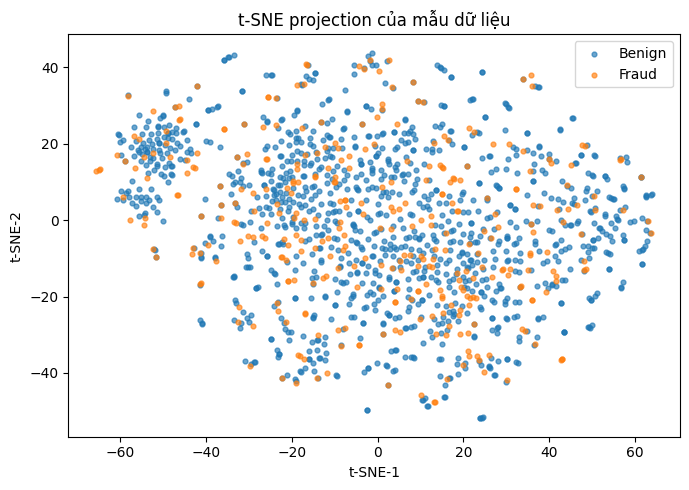

In [ ]:
# 4.3 PCA và t-SNE để quan sát không gian đặc trưng

X_flat = X_all_by_time.reshape(-1, X_all_by_time.shape[-1])
y_flat = y_all_by_time.reshape(-1)

# Lấy mẫu để t-SNE chạy nhanh và biểu đồ dễ nhìn
rng = np.random.default_rng(26541)
sample_size = min(1500, len(X_flat))
sample_idx = rng.choice(len(X_flat), size=sample_size, replace=False)

X_sample = X_flat[sample_idx]
y_sample = y_flat[sample_idx]

# Chuẩn hóa đơn giản để PCA/t-SNE ổn định hơn
mu = X_sample.mean(axis=0, keepdims=True)
sigma = X_sample.std(axis=0, keepdims=True) + 1e-8
X_sample_std = (X_sample - mu) / sigma

pca_2d = PCA(n_components=2, random_state=26541).fit_transform(X_sample_std)

plt.figure(figsize=(7, 5))
for label, name in [(0, "Benign"), (1, "Fraud")]:
    mask = y_sample == label
    plt.scatter(pca_2d[mask, 0], pca_2d[mask, 1], s=12, alpha=0.65, label=name)
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.title("PCA projection của mẫu dữ liệu")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_pca_projection.png", dpi=200)
plt.show()

perplexity = min(30, max(5, (sample_size - 1) // 3))
tsne_2d = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=26541
).fit_transform(X_sample_std)

plt.figure(figsize=(7, 5))
for label, name in [(0, "Benign"), (1, "Fraud")]:
    mask = y_sample == label
    plt.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], s=12, alpha=0.65, label=name)
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.title("t-SNE projection của mẫu dữ liệu")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_tsne_projection.png", dpi=200)
plt.show()

## Giai đoạn 4 — Import thư viện


In [ ]:
import os, sys, json, random, re
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import recall_score


## Giai đoạn 5 — Tạo mã nguồn TA-ACRF-RNN

Các file được tạo trong giai đoạn này:

- `layer_ta_acrf_rnn.py`: attention có masked softmax và CRF update được chỉnh lại.
- `model_ta_acrf_rnn.py`: model trả logits, dùng `ModuleList`, hỗ trợ time-aware relation.
- `main_ta_acrf_rnn.py`: quy trình paper-fair, tune trên 2017 rồi test bằng fixed epoch/threshold.


### 5.1 Ghi `layer_ta_acrf_rnn.py` và `model_ta_acrf_rnn.py`


In [ ]:
# TA-ACRF-RNN — tạo layer_ta_acrf_rnn.py và model_ta_acrf_rnn.py
# Mục tiêu:
# - TA-ACRF-RNN dùng attention softmax + CRF update corrected + logits + Time-aware relation

fixed_layer_ta_acrf_rnn = r"""
import torch
import torch.nn.functional as F
from torch import nn
from util4 import *


class CRF_Att(nn.Module):
    '''Corrected CRF update gần hơn với công thức paper.

    Paper:
        h_i^{k+1} = (alpha*s_i + beta*sum_j f_ij*h_j^k)
                    / (alpha + beta*sum_j f_ij)

    Trong TA-ACRF-RNN:
    - similarity đã được softmax theo từng dòng.
    - không cộng thêm self-loop thủ công như code tác giả.
    '''
    def __init__(self, input_dim, output_dim, num_iters):
        super(CRF_Att, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.num_iters = num_iters
        self.alpha = nn.Parameter(torch.zeros(1).float())
        self.beta  = nn.Parameter(torch.zeros(1).float())

    def forward(self, inputs, similarity):
        support = similarity
        normalize = torch.sum(support, dim=1, keepdim=True).clamp_min(1e-12)

        alpha = torch.exp(self.alpha)
        beta  = torch.exp(self.beta)

        output = inputs
        for _ in range(self.num_iters):
            neighbor = dot(support, output)
            output = (alpha * inputs + beta * neighbor) / (alpha + beta * normalize)

        return output


class Linear(nn.Module):
    def __init__(self, num_nodes, input_size, hidden_size, bias=True):
        super(Linear, self).__init__()
        self.bias = bias
        self.W = nn.Parameter(torch.zeros(num_nodes, input_size, hidden_size))
        self.b = nn.Parameter(torch.zeros(num_nodes, hidden_size))
        self.reset_parameters()

    def reset_parameters(self):
        reset_parameters(self.named_parameters)

    def forward(self, x):
        output = torch.bmm(x.unsqueeze(1), self.W).squeeze(1)
        if self.bias:
            output = output + self.b
        return output


class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, bias=True):
        super(GRUModel, self).__init__()
        self.GRU_layer1 = nn.GRU(input_size=input_dim, hidden_size=2 * hidden_dim)
        self.GRU_layer2 = nn.GRU(input_size=2 * hidden_dim, hidden_size=hidden_dim)
        self.hidden_dim = hidden_dim
        self.hidden = None
        self.reset_parameters()

    def reset_parameters(self):
        reset_parameters(self.named_parameters)

    def forward(self, x):
        x, hidden1 = self.GRU_layer1(x)
        x, hidden2 = self.GRU_layer2(x)
        hidden = hidden2.squeeze(0)
        return hidden


class Attention(nn.Module):
    '''Attention TA-ACRF-RNN: LeakyReLU + masked softmax.

    Code tác giả chỉ LeakyReLU rồi đưa vào CRF.
    TA-ACRF-RNN bổ sung masked softmax:
        logits = logits.masked_fill(mask == 0, -1e9)
        coefs = torch.softmax(logits, dim=1)
    '''
    def __init__(self, in_features, out_features, alpha, num_company, residual=False):
        super(Attention, self).__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.alpha        = alpha
        self.num_company  = num_company

        self.seq_transformation_r = nn.Conv1d(in_features, out_features, kernel_size=1, stride=1, bias=False)
        self.f_1 = nn.Conv1d(out_features, 1, kernel_size=1, stride=1)
        self.f_2 = nn.Conv1d(out_features, 1, kernel_size=1, stride=1)

        self.W_static = nn.Parameter(torch.zeros(self.num_company, self.num_company).float(), requires_grad=True)
        self.leakyrelu = nn.LeakyReLU(self.alpha)

    def forward(self, input_r, relation_static=None):
        device = input_r.device
        num_stock = input_r.shape[0]

        seq_r = torch.transpose(input_r, 0, 1).unsqueeze(0)       # [1, F, N]
        seq_fts_r = self.seq_transformation_r(seq_r)              # [1, H, N]

        f_1 = self.f_1(seq_fts_r)                                 # [1, 1, N]
        f_2 = self.f_2(seq_fts_r)                                 # [1, 1, N]
        logits = (torch.transpose(f_1, 2, 1) + f_2).squeeze(0)     # [N, N]

        if relation_static is not None:
            logits = logits + torch.mul(relation_static.to(device), self.W_static.to(device))

        logits = self.leakyrelu(logits)

        # mask bỏ self-loop, rồi softmax theo từng dòng
        mask = (1.0 - torch.eye(num_stock, device=device, dtype=input_r.dtype))
        logits = logits.masked_fill(mask == 0, -1e9)
        coefs = torch.softmax(logits, dim=1)
        coefs = coefs * mask

        # chống lỗi số học hiếm gặp: chuẩn hóa lại mỗi dòng để tổng xấp xỉ 1
        coefs = coefs / coefs.sum(dim=1, keepdim=True).clamp_min(1e-12)
        return coefs


def myPool(type, crf_embeddings):
    head = len(crf_embeddings)
    feature_num = crf_embeddings[0].size(1)

    if type == "MAX":
        stacked_tensor = torch.stack(crf_embeddings, dim=1)
        pool_embedding = stacked_tensor.view(-1, feature_num).t()
        pool = nn.MaxPool1d(kernel_size=head, stride=head)
        pooled_embedding = pool(pool_embedding).t()
    elif type == "AVG":
        stacked_tensor = torch.stack(crf_embeddings, dim=1)
        pool_embedding = stacked_tensor.view(-1, feature_num).t()
        pool = nn.AvgPool1d(kernel_size=head, stride=head)
        pooled_embedding = pool(pool_embedding).t()
    elif type == "SUM":
        pooled_embedding = torch.sum(torch.stack(crf_embeddings, dim=0), dim=0)
    else:
        raise ValueError(f"Unknown pool type: {type}")

    return pooled_embedding
"""

with open("/content/ACRF-RNN/Code/layer_ta_acrf_rnn.py", "w", encoding="utf-8") as f:
    f.write(fixed_layer_ta_acrf_rnn)

fixed_model_ta_acrf_rnn = r"""
from layer_ta_acrf_rnn import *
from torch import nn
import torch
import torch.nn.functional as F


class AC_RNN(nn.Module):
    def __init__(self, num_company, d_feature, d_hidden, hidn_rnn,
                 heads_att, hidn_att, crf_iters, alpha, pool_type,
                 dropout=0.0, time_aware=True, temporal_lambdas=(0.6, 0.3, 0.1)):
        super(AC_RNN, self).__init__()
        self.heads_att   = heads_att
        self.alpha       = alpha
        self.num_company = num_company
        self.d_feature   = d_feature
        self.d_hidden    = d_hidden
        self.hidden_rnn  = hidn_rnn
        self.hidn_att    = hidn_att
        self.drop_out    = dropout

        self.time_aware = time_aware
        self.temporal_lambdas = tuple(float(x) for x in temporal_lambdas)

        self.GRUs = GRUModel(d_feature, hidn_rnn)
        self.attentions = nn.ModuleList([
            Attention(hidn_rnn, hidn_att, num_company=self.num_company, alpha=self.alpha)
            for _ in range(heads_att)
        ])
        self.crf = CRF_Att(hidn_rnn, hidn_rnn, crf_iters)
        self.pool_type = pool_type
        self.linear = Linear(num_company, hidn_rnn, 2, bias=True)
        self.reset_parameters()

    def reset_parameters(self):
        reset_parameters(self.named_parameters)

    def _normalize_lambdas(self, n):
        lambdas = list(self.temporal_lambdas[:n])
        if len(lambdas) < n:
            remain = n - len(lambdas)
            lambdas += [0.0] * remain
        s = sum(lambdas)
        if s <= 0:
            return [1.0 / n] * n
        return [v / s for v in lambdas]

    def _temporal_embeddings(self, x):
        '''Tạo embedding cho năm hiện tại và các năm liền kề trong window.

        current: GRU(x)
        prev-1 : GRU(x[:-1])
        prev-2 : GRU(x[:-2])

        CRF vẫn cập nhật embedding hiện tại, nhưng similarity được làm giàu bởi
        attention relation của các embedding lịch sử.
        '''
        emb_current = self.GRUs(x)
        embs = [emb_current]

        if self.time_aware:
            if x.size(0) > 1:
                embs.append(self.GRUs(x[:-1]))
            if x.size(0) > 2:
                embs.append(self.GRUs(x[:-2]))

        return embs

    def forward(self, x):
        embs = self._temporal_embeddings(x)
        emb_current = embs[0]
        emb_current = F.dropout(emb_current, p=self.drop_out, training=self.training)

        lambdas = self._normalize_lambdas(len(embs))
        crf_embeddings = []

        for att in self.attentions:
            sims = []
            for emb in embs:
                emb = F.dropout(emb, p=self.drop_out, training=self.training)
                sims.append(att(emb))

            # Time-aware relation:
            # F_tilde = lambda0*F_t + lambda1*F_{t-1} + lambda2*F_{t-2}
            sim_tilde = None
            for w, sim in zip(lambdas, sims):
                sim_tilde = sim * w if sim_tilde is None else sim_tilde + sim * w

            crf_x_attention = self.crf(emb_current, sim_tilde)
            crf_embeddings.append(crf_x_attention)

        crf_x = myPool(self.pool_type, crf_embeddings)

        # Corrected: trả logits thô, KHÔNG softmax trước loss.
        logits = self.linear(crf_x)
        return logits


class FocalLoss(nn.Module):
    '''Weighted Focal Loss nhận logits thô.

    input : logits [N, C]
    target: labels [N]
    '''
    def __init__(self, weight=None, reduction="mean", gamma=1.0, eps=1e-7):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.eps = eps
        self.reduction = reduction
        self.register_buffer("weight", weight if weight is not None else None)

    def forward(self, input, target):
        log_probs = F.log_softmax(input, dim=1)
        probs = torch.exp(log_probs)

        target = target.long().view(-1)
        log_pt = log_probs.gather(1, target.unsqueeze(1)).squeeze(1)
        pt = probs.gather(1, target.unsqueeze(1)).squeeze(1).clamp(min=self.eps, max=1.0 - self.eps)

        if self.weight is not None:
            alpha_t = self.weight.to(input.device).gather(0, target)
        else:
            alpha_t = 1.0

        loss = -alpha_t * ((1.0 - pt) ** self.gamma) * log_pt

        if self.reduction == "sum":
            return loss.sum()
        if self.reduction == "none":
            return loss
        return loss.mean()
"""

with open("/content/ACRF-RNN/Code/model_ta_acrf_rnn.py", "w", encoding="utf-8") as f:
    f.write(fixed_model_ta_acrf_rnn)

print("Đã ghi /content/ACRF-RNN/Code/layer_ta_acrf_rnn.py")
print("Đã ghi /content/ACRF-RNN/Code/model_ta_acrf_rnn.py")
!wc -l /content/ACRF-RNN/Code/layer_ta_acrf_rnn.py /content/ACRF-RNN/Code/model_ta_acrf_rnn.py


Đã ghi /content/ACRF-RNN/Code/layer_ta_acrf_rnn.py
Đã ghi /content/ACRF-RNN/Code/model_ta_acrf_rnn.py
 147 /content/ACRF-RNN/Code/layer_ta_acrf_rnn.py
 131 /content/ACRF-RNN/Code/model_ta_acrf_rnn.py
 278 total


### 5.2 Ghi `main_ta_acrf_rnn.py` — TA-ACRF-RNN paper-fair


In [ ]:
# main_ta_acrf_rnn.py — TA-ACRF-RNN paper-fair
# Quy trình:
# 1. mode=tune: train các năm trước 2017, tune epoch + threshold trên val_year=2017.
# 2. mode=test: train full các năm trước test_year, KHÔNG chọn best theo test,
#    chỉ train đúng fixed_epoch và đánh giá bằng fixed_threshold lấy từ bước tune.

fixed_main_ta_acrf_rnn = r"""
import os, sys, json, random, copy
import numpy as np
import torch
from torch import optim
import argparse
from model_ta_acrf_rnn import *
from util4 import *
from sklearn.metrics import recall_score

parser = argparse.ArgumentParser()

# Data / split
parser.add_argument("--data-path", type=str, default="/content/project_data/processed_flat.json")
parser.add_argument("--mode", type=str, default="tune", choices=["tune", "test"])
parser.add_argument("--test-year", type=int, default=2019)
parser.add_argument("--val-year", type=int, default=2017)

# Model
parser.add_argument("--rnn-length", type=int, default=3)
parser.add_argument("--heads-att", type=int, default=3)
parser.add_argument("--hidn-att", type=int, default=24)
parser.add_argument("--hidn-rnn", type=int, default=48)
parser.add_argument("--crf-iter", type=int, default=3)
parser.add_argument("--alpha", type=float, default=0.5)
parser.add_argument("--pool-type", type=int, default=3)
parser.add_argument("--dropout", type=float, default=0.2)

# Training
parser.add_argument("--max-epoch", type=int, default=300)
parser.add_argument("--wait-epoch", type=int, default=80)
parser.add_argument("--batch-train", type=int, default=4)
parser.add_argument("--clip", type=float, default=0.5)
parser.add_argument("--seed", type=int, default=26541)
parser.add_argument("--lr", type=float, default=0.003)
parser.add_argument("--device", type=str, default="0")

# Loss
parser.add_argument("--gamma", type=float, default=2.0)
parser.add_argument("--n-weight", type=float, default=0.10)
parser.add_argument("--f-weight", type=float, default=0.25)

# Time-aware relation
parser.add_argument("--time-aware", type=int, default=1)
parser.add_argument("--lambda-current", type=float, default=0.7)
parser.add_argument("--lambda-prev1", type=float, default=0.2)
parser.add_argument("--lambda-prev2", type=float, default=0.1)

# Threshold tuning
parser.add_argument("--thr-min", type=float, default=0.30)
parser.add_argument("--thr-max", type=float, default=0.70)
parser.add_argument("--thr-step", type=float, default=0.01)

# Test mode: dùng kết quả lấy từ mode=tune
parser.add_argument("--fixed-epoch", type=int, default=40)
parser.add_argument("--fixed-threshold", type=float, default=0.68)

pool_dic = {1: "MAX", 2: "AVG", 3: "SUM"}
args = parser.parse_args()

rnn_len = args.rnn_length
pool_type = pool_dic[args.pool_type]
DEVICE = f"cuda:{args.device}" if torch.cuda.is_available() else "cpu"

torch.manual_seed(args.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(args.seed)
np.random.seed(args.seed)
random.seed(args.seed)


def load_all(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    years = [b["year"] for b in payload["data"]]
    rows = [b["rows"] for b in payload["data"]]

    data = torch.from_numpy(np.array(rows, dtype=np.float32)).float()
    x = data[:, :, :-1]
    y = data[:, :, -1].unsqueeze(-1).long()

    print(f"Loaded: {len(years)} years | x={tuple(x.shape)} | y={tuple(y.shape)}")
    print(f"Years : {years}")
    return years, x, y


def build_blocks(years, x, y):
    if args.mode == "tune":
        if args.val_year not in years:
            raise ValueError(f"val_year {args.val_year} not in {years}")

        val_idx = years.index(args.val_year)

        # Vì dữ liệu hiện tại không có năm 2016:
        # train: 2010–2015
        # val  : 2017
        x_train = x[:val_idx]
        y_train = y[:val_idx]

        val_start = max(0, val_idx - rnn_len)
        x_eval = x[val_start:val_idx + 1]
        y_eval = y[val_start:val_idx + 1]

        print("=" * 105)
        print("MODE = TUNE")
        print(f"Train : {years[:val_idx]} ({x_train.shape[0]} years)")
        print(f"Val   : {years[val_start:val_idx + 1]} -> tune epoch + threshold, report val_year={args.val_year}")
        print("=" * 105)

    else:
        if args.test_year not in years:
            raise ValueError(f"test_year {args.test_year} not in {years}")

        test_idx = years.index(args.test_year)

        # Paper-fair test: train full toàn bộ lịch sử trước test_year.
        # Không dùng test để chọn best epoch / threshold.
        x_train = x[:test_idx]
        y_train = y[:test_idx]

        test_start = max(0, test_idx - rnn_len)
        x_eval = x[test_start:test_idx + 1]
        y_eval = y[test_start:test_idx + 1]

        print("=" * 105)
        print("MODE = TEST")
        print(f"Train : {years[:test_idx]} ({x_train.shape[0]} years) -- full history before test_year")
        print(f"Test  : {years[test_start:test_idx + 1]} -> report test_year={args.test_year}")
        print(f"Fixed epoch     = {args.fixed_epoch}")
        print(f"Fixed threshold = {args.fixed_threshold}")
        print("=" * 105)

    n_fraud = int((y_train == 1).sum())
    n_benign = int((y_train == 0).sum())
    print(f"Train labels: fraud={n_fraud}, benign={n_benign}")

    return x_train, y_train, x_eval, y_eval


def metric_from_probs(y_true, prob_fraud, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    prob_fraud = np.asarray(prob_fraud).reshape(-1)
    y_pred = (prob_fraud >= threshold).astype(int)

    acc = (y_pred == y_true).mean()
    rcl = recall_score(y_true, y_pred, average="macro", zero_division=0)
    ks = KS(y_true, prob_fraud)
    gm = GM(y_true, y_pred)

    score = 0.35 * ks + 0.35 * gm + 0.20 * rcl + 0.10 * acc
    return acc, rcl, ks, gm, score


def tune_threshold(y_true, prob_fraud):
    thresholds = np.arange(args.thr_min, args.thr_max + 1e-9, args.thr_step)
    best = None

    for thr in thresholds:
        acc, rcl, ks, gm, score = metric_from_probs(y_true, prob_fraud, thr)
        row = {
            "threshold": float(thr),
            "acc": acc,
            "recall_macro": rcl,
            "ks": ks,
            "gm": gm,
            "score": score,
        }
        if best is None or row["score"] > best["score"]:
            best = row

    return best


def collect_logits(model, x_block, y_block):
    model.eval()
    seq_len = len(x_block)
    seq = list(range(seq_len))[rnn_len:]

    logits_list, y_list = [], []

    with torch.no_grad():
        for i in seq:
            x_i = x_block[i - rnn_len + 1:i + 1].to(DEVICE)
            logits = model(x_i)
            logits_list.append(logits.detach().cpu())
            y_list.append(y_block[i].view(-1).detach().cpu())

    if not logits_list:
        return None, None

    logits_all = torch.cat(logits_list, dim=0)
    y_all = torch.cat(y_list, dim=0).numpy()
    return logits_all, y_all


def evaluate(model, x_block, y_block, threshold=None, tune=False):
    logits_all, y_true = collect_logits(model, x_block, y_block)

    if logits_all is None:
        return {"threshold": 0.5, "acc": 0.0, "recall_macro": 0.0, "ks": 0.0, "gm": 0.0, "score": 0.0}

    probs = torch.softmax(logits_all, dim=1).numpy()
    prob_fraud = probs[:, 1]

    if tune:
        return tune_threshold(y_true, prob_fraud)

    if threshold is None:
        threshold = 0.5

    acc, rcl, ks, gm, score = metric_from_probs(y_true, prob_fraud, threshold)
    return {"threshold": float(threshold), "acc": acc, "recall_macro": rcl, "ks": ks, "gm": gm, "score": score}


def train_metrics_from_logits(y_true_all, logits_all):
    if len(logits_all) == 0:
        return 0.0, 0.0, 0.0

    logits_all = torch.cat(logits_all, dim=0)
    probs = torch.softmax(logits_all, dim=1).detach().cpu().numpy()
    y_true = torch.cat(y_true_all, dim=0).detach().cpu().numpy()

    acc, rcl, ks, gm, score = metric_from_probs(y_true, probs[:, 1], threshold=0.5)
    return acc, rcl, ks


def do_train(model, x_train, y_train, optimizer, criterion):
    model.train()

    seq_len = len(x_train)
    train_seq = list(range(seq_len))[rnn_len:]

    if not train_seq:
        return 0.0, 0.0, 0.0, 0.0

    random.shuffle(train_seq)

    total_loss, cnt = 0.0, 0
    logits_for_metric, y_for_metric = [], []

    optimizer.zero_grad()

    for step, i in enumerate(train_seq, start=1):
        x_i = x_train[i - rnn_len + 1:i + 1].to(DEVICE)
        y_i = y_train[i].to(DEVICE).view(-1).long()

        logits = model(x_i)
        loss = criterion(logits, y_i)
        loss.backward()

        total_loss += loss.item()
        cnt += 1

        logits_for_metric.append(logits.detach().cpu())
        y_for_metric.append(y_i.detach().cpu())

        if step % args.batch_train == 0 or step == len(train_seq):
            torch.nn.utils.clip_grad_norm_(model.parameters(), args.clip)
            optimizer.step()
            optimizer.zero_grad()

    train_acc, train_rcl, train_ks = train_metrics_from_logits(y_for_metric, logits_for_metric)
    return total_loss / max(cnt, 1), train_acc, train_rcl, train_ks


if __name__ == "__main__":
    os.makedirs("/content/project_outputs", exist_ok=True)
    os.makedirs("/content/project_outputs/checkpoints_ta_acrf_rnn", exist_ok=True)

    years, x, y = load_all(args.data_path)
    x_train, y_train, x_eval, y_eval = build_blocks(years, x, y)

    num_company = x_train.size(1)
    d_feature = x_train.size(2)
    d_hidden = d_feature

    class_weight = torch.tensor([args.n_weight, args.f_weight]).float().to(DEVICE)
    criterion = FocalLoss(weight=class_weight, gamma=args.gamma)

    model = AC_RNN(
        num_company=num_company,
        d_feature=d_feature,
        d_hidden=d_hidden,
        hidn_rnn=args.hidn_rnn,
        heads_att=args.heads_att,
        hidn_att=args.hidn_att,
        crf_iters=args.crf_iter,
        alpha=args.alpha,
        pool_type=pool_type,
        dropout=args.dropout,
        time_aware=bool(args.time_aware),
        temporal_lambdas=(args.lambda_current, args.lambda_prev1, args.lambda_prev2),
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=args.lr)

    print("TA-ACRF-RNN PAPER-FAIR | Corrected ACRF-RNN + Time-aware relation + fixed threshold")
    print(f"mode={args.mode} | device={DEVICE}")
    print(f"rnn_length={args.rnn_length} | lr={args.lr} | dropout={args.dropout}")
    print(f"hidn_rnn={args.hidn_rnn} | hidn_att={args.hidn_att} | heads_att={args.heads_att} | crf_iter={args.crf_iter}")
    print(f"time_aware={bool(args.time_aware)} | lambdas=({args.lambda_current}, {args.lambda_prev1}, {args.lambda_prev2})")
    print(f"threshold grid=[{args.thr_min}, {args.thr_max}], step={args.thr_step}")
    print("=" * 105)
    print("epoch | loss | train_acc | eval_acc | eval_recall_m | eval_ks | eval_gm | threshold | val_score")

    best_score = -1.0
    best_epoch = -1
    best_threshold = args.fixed_threshold
    best_eval_m = None
    wait_epoch = 0

    if args.mode == "tune":
        for epoch in range(args.max_epoch):
            train_loss, train_acc, train_rcl, train_ks = do_train(model, x_train, y_train, optimizer, criterion)
            eval_m = evaluate(model, x_eval, y_eval, tune=True)

            print(f"{epoch:04d} | {train_loss:.4f} | {train_acc:.4f} | "
                  f"{eval_m['acc']:.4f} | {eval_m['recall_macro']:.4f} | "
                  f"{eval_m['ks']:.4f} | {eval_m['gm']:.4f} | "
                  f"{eval_m['threshold']:.2f} | {eval_m['score']:.4f}")

            if eval_m["score"] > best_score:
                best_score = eval_m["score"]
                best_epoch = epoch
                best_threshold = eval_m["threshold"]
                best_eval_m = eval_m
                wait_epoch = 0
            else:
                wait_epoch += 1

            if wait_epoch > args.wait_epoch:
                print(f"Early stopping at epoch={epoch}, best_epoch={best_epoch}, best_val_score={best_score:.4f}")
                break

        print("=" * 105)
        print(f"TUNE_RESULT | best_epoch={best_epoch} | best_threshold={best_threshold:.2f} | "
              f"val_acc={best_eval_m['acc']:.4f} | val_recall_m={best_eval_m['recall_macro']:.4f} | "
              f"val_ks={best_eval_m['ks']:.4f} | val_gm={best_eval_m['gm']:.4f} | "
              f"val_score={best_score:.4f}")
        print("=" * 105)

    else:
        final_m = None
        for epoch in range(args.fixed_epoch + 1):
            train_loss, train_acc, train_rcl, train_ks = do_train(model, x_train, y_train, optimizer, criterion)

            # In để theo dõi, nhưng không dùng test để chọn model.
            if epoch % 5 == 0 or epoch == args.fixed_epoch:
                final_m = evaluate(model, x_eval, y_eval, threshold=args.fixed_threshold, tune=False)
                print(f"{epoch:04d} | {train_loss:.4f} | {train_acc:.4f} | "
                      f"{final_m['acc']:.4f} | {final_m['recall_macro']:.4f} | "
                      f"{final_m['ks']:.4f} | {final_m['gm']:.4f} | "
                      f"{args.fixed_threshold:.2f} | {final_m['score']:.4f}")

        final_m = evaluate(model, x_eval, y_eval, threshold=args.fixed_threshold, tune=False)

        print("=" * 105)
        print(f"BEST_TEST | epoch={args.fixed_epoch} | acc={final_m['acc']:.4f} | "
              f"recall_m={final_m['recall_macro']:.4f} | ks={final_m['ks']:.4f} | "
              f"gm={final_m['gm']:.4f} | threshold={args.fixed_threshold:.2f} | "
              f"val_score={final_m['score']:.4f}")
        print("=" * 105)

        paper = {
            2018: (77.60, 70.79, 41.58, 69.37),
            2019: (80.45, 75.44, 50.88, 74.89),
            2020: (79.43, 71.96, 43.92, 71.04),
        }
        p = paper.get(args.test_year, (0, 0, 0, 0))

        print(f"KET QUA TA-ACRF-RNN PAPER-FAIR -- test_year={args.test_year}")
        print(f"Fixed epoch from tune: {args.fixed_epoch}")
        print(f"Fixed threshold from tune: {args.fixed_threshold:.2f}")
        print("Metric         Paper   TA-ACRF-RNN    Diff")
        print("----------------------------------------")
        names = ["Accuracy", "Recall_m", "KS", "G-mean"]
        vals = [
            final_m["acc"] * 100,
            final_m["recall_macro"] * 100,
            final_m["ks"] * 100,
            final_m["gm"] * 100,
        ]

        for name, pv, vv in zip(names, p, vals):
            print(f"{name:<12} {pv:7.2f} {vv:7.2f} {vv - pv:+6.2f}")
"""

with open("/content/ACRF-RNN/Code/main_ta_acrf_rnn.py", "w", encoding="utf-8") as f:
    f.write(fixed_main_ta_acrf_rnn)

print("Đã ghi đè /content/ACRF-RNN/Code/main_ta_acrf_rnn.py theo TA-ACRF-RNN paper-fair")
!python -m py_compile /content/ACRF-RNN/Code/main_ta_acrf_rnn.py


Đã ghi đè /content/ACRF-RNN/Code/main_ta_acrf_rnn.py theo TA-ACRF-RNN paper-fair


## Giai đoạn 6 — Tune trên validation year 2017


In [ ]:
%cd /content/ACRF-RNN/Code
!python main_ta_acrf_rnn.py \
    --mode tune \
    --data-path /content/project_data/processed_flat.json \
    --val-year 2017 \
    --rnn-length 3 \
    --max-epoch 300 --wait-epoch 80 --device 0 \
    --lr 0.003 \
    --dropout 0.2 \
    --gamma 2 \
    --f-weight 0.25 \
    --n-weight 0.10 \
    --clip 0.5 \
    --hidn-rnn 48 \
    --hidn-att 24 \
    --heads-att 3 \
    --crf-iter 3 \
    --lambda-current 0.7 \
    --lambda-prev1 0.2 \
    --lambda-prev2 0.1 \
    --thr-min 0.30 \
    --thr-max 0.70 \
    2>&1 | tee /content/project_outputs/run_ta_acrf_rnn_tune_2017.log


/content/ACRF-RNN/Code
Loaded: 10 years | x=(10, 491, 208) | y=(10, 491, 1)
Years : [2010, 2011, 2012, 2013, 2014, 2015, 2017, 2018, 2019, 2020]
MODE = TUNE
Train : [2010, 2011, 2012, 2013, 2014, 2015] (6 years)
Val   : [2013, 2014, 2015, 2017] -> tune epoch + threshold, report val_year=2017
Lưu ý: Dataset không có năm 2016, nên train tune kết thúc ở 2015.
Train labels: fraud=738, benign=2208
TA-ACRF-RNN PAPER-FAIR | Corrected ACRF-RNN + Time-aware relation + fixed threshold
mode=tune | device=cuda:0
rnn_length=3 | lr=0.003 | dropout=0.2
hidn_rnn=48 | hidn_att=24 | heads_att=3 | crf_iter=3
time_aware=True | lambdas=(0.7, 0.2, 0.1)
threshold grid=[0.3, 0.7], step=0.01
epoch | loss | train_acc | eval_acc | eval_recall_m | eval_ks | eval_gm | threshold | val_score
0000 | 0.0690 | 0.5044 | 0.5621 | 0.5496 | 0.1225 | 0.5490 | 0.53 | 0.4011
0001 | 0.0578 | 0.5479 | 0.5845 | 0.5699 | 0.1427 | 0.5692 | 0.52 | 0.4216
0002 | 0.0490 | 0.5757 | 0.6090 | 0.5807 | 0.1642 | 0.5780 | 0.54 | 0.4368
000

Sau khi chạy cell tune, kiểm tra dòng:

```text
TUNE_RESULT | best_epoch=40 | best_threshold=0.68 | ...
```

Các cell test bên dưới đang dùng sẵn `fixed_epoch=40` và `fixed_threshold=0.68`. Nếu kết quả tune thay đổi, sửa lại hai tham số này trong các cell test.


## Giai đoạn 7 — Test TA-ACRF-RNN paper-fair


### 7.1 Test year 2018


In [ ]:
%cd /content/ACRF-RNN/Code
!python main_ta_acrf_rnn.py \
    --mode test \
    --data-path /content/project_data/processed_flat.json \
    --test-year 2018 \
    --fixed-epoch 40 \
    --fixed-threshold 0.68 \
    --rnn-length 3 \
    --max-epoch 300 --wait-epoch 80 --device 0 \
    --lr 0.003 \
    --dropout 0.2 \
    --gamma 2 \
    --f-weight 0.25 \
    --n-weight 0.10 \
    --clip 0.5 \
    --hidn-rnn 48 \
    --hidn-att 24 \
    --heads-att 3 \
    --crf-iter 3 \
    --lambda-current 0.7 \
    --lambda-prev1 0.2 \
    --lambda-prev2 0.1 \
    --thr-min 0.30 \
    --thr-max 0.70 \
    2>&1 | tee /content/project_outputs/run_ta_acrf_rnn_2018.log


/content/ACRF-RNN/Code
Loaded: 10 years | x=(10, 491, 208) | y=(10, 491, 1)
Years : [2010, 2011, 2012, 2013, 2014, 2015, 2017, 2018, 2019, 2020]
MODE = TEST
Train : [2010, 2011, 2012, 2013, 2014, 2015, 2017] (7 years) -- full history before test_year
Test  : [2014, 2015, 2017, 2018] -> report test_year=2018
Fixed epoch     = 40
Fixed threshold = 0.68
Train labels: fraud=860, benign=2577
TA-ACRF-RNN PAPER-FAIR | Corrected ACRF-RNN + Time-aware relation + fixed threshold
mode=test | device=cuda:0
rnn_length=3 | lr=0.003 | dropout=0.2
hidn_rnn=48 | hidn_att=24 | heads_att=3 | crf_iter=3
time_aware=True | lambdas=(0.7, 0.2, 0.1)
threshold grid=[0.3, 0.7], step=0.01
epoch | loss | train_acc | eval_acc | eval_recall_m | eval_ks | eval_gm | threshold | val_score
0000 | 0.0678 | 0.5143 | 0.5886 | 0.4841 | 0.0548 | 0.4331 | 0.68 | 0.3264
0005 | 0.0324 | 0.6604 | 0.6619 | 0.5387 | 0.1490 | 0.4744 | 0.68 | 0.3921
0010 | 0.0146 | 0.7999 | 0.7413 | 0.6179 | 0.2787 | 0.5625 | 0.68 | 0.4921
0015 | 0.

### 7.2 Test year 2019


In [ ]:
%cd /content/ACRF-RNN/Code
!python main_ta_acrf_rnn.py \
    --mode test \
    --data-path /content/project_data/processed_flat.json \
    --test-year 2019 \
    --fixed-epoch 40 \
    --fixed-threshold 0.68 \
    --rnn-length 3 \
    --max-epoch 300 --wait-epoch 80 --device 0 \
    --lr 0.003 \
    --dropout 0.2 \
    --gamma 2 \
    --f-weight 0.25 \
    --n-weight 0.10 \
    --clip 0.5 \
    --hidn-rnn 48 \
    --hidn-att 24 \
    --heads-att 3 \
    --crf-iter 3 \
    --lambda-current 0.7 \
    --lambda-prev1 0.2 \
    --lambda-prev2 0.1 \
    --thr-min 0.30 \
    --thr-max 0.70 \
    2>&1 | tee /content/project_outputs/run_ta_acrf_rnn_2019.log


/content/ACRF-RNN/Code
Loaded: 10 years | x=(10, 491, 208) | y=(10, 491, 1)
Years : [2010, 2011, 2012, 2013, 2014, 2015, 2017, 2018, 2019, 2020]
MODE = TEST
Train : [2010, 2011, 2012, 2013, 2014, 2015, 2017, 2018] (8 years) -- full history before test_year
Test  : [2015, 2017, 2018, 2019] -> report test_year=2019
Fixed epoch     = 40
Fixed threshold = 0.68
Train labels: fraud=987, benign=2941
TA-ACRF-RNN PAPER-FAIR | Corrected ACRF-RNN + Time-aware relation + fixed threshold
mode=test | device=cuda:0
rnn_length=3 | lr=0.003 | dropout=0.2
hidn_rnn=48 | hidn_att=24 | heads_att=3 | crf_iter=3
time_aware=True | lambdas=(0.7, 0.2, 0.1)
threshold grid=[0.3, 0.7], step=0.01
epoch | loss | train_acc | eval_acc | eval_recall_m | eval_ks | eval_gm | threshold | val_score
0000 | 0.0684 | 0.5157 | 0.6538 | 0.5409 | 0.0896 | 0.5007 | 0.68 | 0.3802
0005 | 0.0215 | 0.7413 | 0.7454 | 0.6096 | 0.3473 | 0.5578 | 0.68 | 0.5132
0010 | 0.0090 | 0.8811 | 0.7882 | 0.6825 | 0.4729 | 0.6550 | 0.68 | 0.6101
001

### 7.3 Test year 2020


In [ ]:
%cd /content/ACRF-RNN/Code
!python main_ta_acrf_rnn.py \
    --mode test \
    --data-path /content/project_data/processed_flat.json \
    --test-year 2020 \
    --fixed-epoch 40 \
    --fixed-threshold 0.68 \
    --rnn-length 3 \
    --max-epoch 300 --wait-epoch 80 --device 0 \
    --lr 0.003 \
    --dropout 0.2 \
    --gamma 2 \
    --f-weight 0.25 \
    --n-weight 0.10 \
    --clip 0.5 \
    --hidn-rnn 48 \
    --hidn-att 24 \
    --heads-att 3 \
    --crf-iter 3 \
    --lambda-current 0.7 \
    --lambda-prev1 0.2 \
    --lambda-prev2 0.1 \
    --thr-min 0.30 \
    --thr-max 0.70 \
    2>&1 | tee /content/project_outputs/run_ta_acrf_rnn_2020.log


/content/ACRF-RNN/Code
Loaded: 10 years | x=(10, 491, 208) | y=(10, 491, 1)
Years : [2010, 2011, 2012, 2013, 2014, 2015, 2017, 2018, 2019, 2020]
MODE = TEST
Train : [2010, 2011, 2012, 2013, 2014, 2015, 2017, 2018, 2019] (9 years) -- full history before test_year
Test  : [2017, 2018, 2019, 2020] -> report test_year=2020
Fixed epoch     = 40
Fixed threshold = 0.68
Train labels: fraud=1097, benign=3322
TA-ACRF-RNN PAPER-FAIR | Corrected ACRF-RNN + Time-aware relation + fixed threshold
mode=test | device=cuda:0
rnn_length=3 | lr=0.003 | dropout=0.2
hidn_rnn=48 | hidn_att=24 | heads_att=3 | crf_iter=3
time_aware=True | lambdas=(0.7, 0.2, 0.1)
threshold grid=[0.3, 0.7], step=0.01
epoch | loss | train_acc | eval_acc | eval_recall_m | eval_ks | eval_gm | threshold | val_score
0000 | 0.0681 | 0.5177 | 0.6660 | 0.5182 | 0.0682 | 0.4656 | 0.68 | 0.3570
0005 | 0.0205 | 0.7485 | 0.7821 | 0.6160 | 0.3282 | 0.5605 | 0.68 | 0.5125
0010 | 0.0096 | 0.8737 | 0.8228 | 0.6728 | 0.3634 | 0.6319 | 0.68 | 0.5

## Giai đoạn 8 — Chạy baseline độc lập: Random Forest và XGBoost

Hai mô hình này không dùng GRU, Attention, CRF hay Time-aware relation. Mục tiêu là tạo baseline độc lập trên dữ liệu dạng bảng để so sánh với Paper và TA-ACRF-RNN.

Thiết lập thực nghiệm giữ cùng logic paper-fair:

```text
Tune threshold: train 2010–2015, validation 2017
Test 2018: train toàn bộ lịch sử trước 2018, test 2018
Test 2019: train toàn bộ lịch sử trước 2019, test 2019
Test 2020: train toàn bộ lịch sử trước 2020, test 2020
```


In [ ]:
# Baseline độc lập: Random Forest và XGBoost
# Kết quả được lưu vào: /content/project_outputs/baseline_rf_xgb_results.csv

import os, sys, subprocess, textwrap

# Cài XGBoost nếu môi trường chưa có
try:
    import xgboost  # noqa: F401
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])

baseline_script = r"""
import os, json, random, warnings
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, roc_curve
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

DATA_PATH = "/content/project_data/processed_flat.json"
OUT_DIR = "/content/project_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 26541
np.random.seed(SEED)
random.seed(SEED)


def load_flat(path):
    with open(path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    years = [b["year"] for b in payload["data"]]
    rows = np.array([b["rows"] for b in payload["data"]], dtype=np.float32)

    X = rows[:, :, :-1]
    y = rows[:, :, -1].astype(int)

    print(f"Loaded: {len(years)} years | X={X.shape} | y={y.shape}")
    print(f"Years : {years}")
    return years, X, y


def make_xy(years, X, y, selected_years):
    idxs = [years.index(yy) for yy in selected_years]
    X_out = X[idxs].reshape(-1, X.shape[-1])
    y_out = y[idxs].reshape(-1)
    return X_out, y_out


def ks_score(y_true, prob_fraud):
    y_true = np.asarray(y_true).astype(int)
    prob_fraud = np.asarray(prob_fraud)
    if len(np.unique(y_true)) < 2:
        return 0.0
    fpr, tpr, _ = roc_curve(y_true, prob_fraud)
    return float(np.max(tpr - fpr))


def gm_score(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    sens = tp / (tp + fn + 1e-12)
    spec = tn / (tn + fp + 1e-12)
    return float(np.sqrt(sens * spec))


def metric_from_probs(y_true, prob_fraud, threshold):
    y_pred = (prob_fraud >= threshold).astype(int)
    acc = float(np.mean(y_pred == y_true))
    rcl = float(recall_score(y_true, y_pred, average="macro", zero_division=0))
    ks = ks_score(y_true, prob_fraud)
    gm = gm_score(y_true, y_pred)
    score = 0.35 * ks + 0.35 * gm + 0.20 * rcl + 0.10 * acc
    return acc, rcl, ks, gm, score


def tune_threshold(y_true, prob_fraud, thr_min=0.30, thr_max=0.70, thr_step=0.01):
    best = None
    for thr in np.arange(thr_min, thr_max + 1e-9, thr_step):
        acc, rcl, ks, gm, score = metric_from_probs(y_true, prob_fraud, thr)
        row = {
            "threshold": float(thr),
            "acc": acc,
            "recall_m": rcl,
            "ks": ks,
            "gm": gm,
            "score": score,
        }
        if best is None or row["score"] > best["score"]:
            best = row
    return best


def build_model(model_name, y_train):
    n_pos = max(int(np.sum(y_train == 1)), 1)
    n_neg = max(int(np.sum(y_train == 0)), 1)
    scale_pos_weight = n_neg / n_pos

    if model_name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=500,
            max_depth=8,
            min_samples_leaf=3,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1,
        )

    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=400,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            reg_alpha=0.1,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=SEED,
            n_jobs=-1,
            tree_method="hist",
        )

    raise ValueError(model_name)


def predict_prob_fraud(model, X_test):
    proba = model.predict_proba(X_test)
    if proba.shape[1] == 1:
        return np.zeros(len(X_test), dtype=float)
    return proba[:, 1]


def main():
    years, X, y = load_flat(DATA_PATH)

    if 2017 not in years:
        raise ValueError("Không tìm thấy năm 2017 để tune threshold")

    val_year = 2017
    val_idx = years.index(val_year)
    train_tune_years = years[:val_idx]

    print("=" * 100)
    print("BASELINE TUNE THRESHOLD")
    print(f"Train tune: {train_tune_years}")
    print(f"Val tune  : {val_year}")
    print("=" * 100)

    X_tune_train, y_tune_train = make_xy(years, X, y, train_tune_years)
    X_val, y_val = make_xy(years, X, y, [val_year])

    tune_rows = []
    test_rows = []

    for model_name in ["RandomForest", "XGBoost"]:
        print("\n" + "-" * 100)
        print(f"Tuning threshold for {model_name}")

        model = build_model(model_name, y_tune_train)
        model.fit(X_tune_train, y_tune_train)
        val_prob = predict_prob_fraud(model, X_val)
        best_thr = tune_threshold(y_val, val_prob)

        tune_rows.append({
            "model": model_name,
            "best_threshold": best_thr["threshold"],
            "val_acc": best_thr["acc"] * 100,
            "val_recall_m": best_thr["recall_m"] * 100,
            "val_ks": best_thr["ks"] * 100,
            "val_gm": best_thr["gm"] * 100,
            "val_score": best_thr["score"],
        })

        print(
            f"TUNE_RESULT | model={model_name} | threshold={best_thr['threshold']:.2f} | "
            f"val_acc={best_thr['acc']:.4f} | val_recall_m={best_thr['recall_m']:.4f} | "
            f"val_ks={best_thr['ks']:.4f} | val_gm={best_thr['gm']:.4f} | val_score={best_thr['score']:.4f}"
        )

        fixed_threshold = best_thr["threshold"]

        for test_year in [2018, 2019, 2020]:
            if test_year not in years:
                continue

            test_idx = years.index(test_year)
            train_years = years[:test_idx]

            X_train, y_train = make_xy(years, X, y, train_years)
            X_test, y_test = make_xy(years, X, y, [test_year])

            model = build_model(model_name, y_train)
            model.fit(X_train, y_train)
            test_prob = predict_prob_fraud(model, X_test)
            acc, rcl, ks, gm, score = metric_from_probs(y_test, test_prob, fixed_threshold)

            row = {
                "model": model_name,
                "test_year": test_year,
                "train_years": ",".join(map(str, train_years)),
                "threshold": fixed_threshold,
                "Accuracy": acc * 100,
                "Recall_m": rcl * 100,
                "KS": ks * 100,
                "G-mean": gm * 100,
                "score": score,
            }
            test_rows.append(row)

            print(
                f"BASELINE_TEST | model={model_name} | test_year={test_year} | "
                f"threshold={fixed_threshold:.2f} | acc={acc:.4f} | recall_m={rcl:.4f} | "
                f"ks={ks:.4f} | gm={gm:.4f} | score={score:.4f}"
            )

    tune_df = pd.DataFrame(tune_rows)
    test_df = pd.DataFrame(test_rows)

    tune_path = os.path.join(OUT_DIR, "baseline_rf_xgb_tune_2017.csv")
    result_path = os.path.join(OUT_DIR, "baseline_rf_xgb_results.csv")

    tune_df.to_csv(tune_path, index=False)
    test_df.to_csv(result_path, index=False)

    print("\n" + "=" * 100)
    print("BASELINE RESULTS")
    print(test_df[["model", "test_year", "Accuracy", "Recall_m", "KS", "G-mean", "threshold"]].round(2).to_string(index=False))
    print("=" * 100)
    print(f"Saved tune  : {tune_path}")
    print(f"Saved result: {result_path}")


if __name__ == "__main__":
    main()
"""

with open("/content/ACRF-RNN/Code/main_tabular_baselines.py", "w", encoding="utf-8") as f:
    f.write(baseline_script)

print("Đã ghi /content/ACRF-RNN/Code/main_tabular_baselines.py")
!python -m py_compile /content/ACRF-RNN/Code/main_tabular_baselines.py

%cd /content/ACRF-RNN/Code
!python main_tabular_baselines.py 2>&1 | tee /content/project_outputs/run_baseline_rf_xgb.log


Đã ghi /content/ACRF-RNN/Code/main_tabular_baselines.py
/content/ACRF-RNN/Code
Loaded: 10 years | X=(10, 491, 208) | y=(10, 491)
Years : [2010, 2011, 2012, 2013, 2014, 2015, 2017, 2018, 2019, 2020]
BASELINE TUNE THRESHOLD
Train tune: [2010, 2011, 2012, 2013, 2014, 2015]
Val tune  : 2017

----------------------------------------------------------------------------------------------------
Tuning threshold for RandomForest
TUNE_RESULT | model=RandomForest | threshold=0.43 | val_acc=0.5479 | val_recall_m=0.5373 | val_ks=0.1051 | val_gm=0.5369 | val_score=0.3870
BASELINE_TEST | model=RandomForest | test_year=2018 | threshold=0.43 | acc=0.5723 | recall_m=0.6090 | ks=0.2505 | gm=0.6042 | score=0.4782
BASELINE_TEST | model=RandomForest | test_year=2019 | threshold=0.43 | acc=0.6375 | recall_m=0.6985 | ks=0.4214 | gm=0.6897 | score=0.5923
BASELINE_TEST | model=RandomForest | test_year=2020 | threshold=0.43 | acc=0.6171 | recall_m=0.6809 | ks=0.3906 | gm=0.6738 | score=0.5704

------------------

## Giai đoạn 9 — Tổng hợp và so sánh Paper, Random Forest, XGBoost và TA-ACRF-RNN

Cell này đọc log của TA-ACRF-RNN và file kết quả baseline để tạo bảng so sánh theo từng năm kiểm thử, đồng thời tính trung bình 3 năm.


In [ ]:
import os, re, pandas as pd

paper_values = {
    2018: {"Accuracy": 77.60, "Recall_m": 70.79, "KS": 41.58, "G-mean": 69.37},
    2019: {"Accuracy": 80.45, "Recall_m": 75.44, "KS": 50.88, "G-mean": 74.89},
    2020: {"Accuracy": 79.43, "Recall_m": 71.96, "KS": 43.92, "G-mean": 71.04},
}

best_pat = re.compile(
    r"BEST_TEST\s*\|\s*epoch=(\d+)\s*\|\s*acc=([\d.]+)\s*\|"
    r"\s*recall_m=([\d.]+)\s*\|\s*ks=([\d.]+)\s*\|"
    r"\s*gm=([\d.]+)\s*\|\s*threshold=([\d.]+)\s*\|\s*val_score=([\d.]+)"
)

tune_pat = re.compile(
    r"TUNE_RESULT\s*\|\s*best_epoch=(\d+)\s*\|\s*best_threshold=([\d.]+)\s*\|"
    r"\s*val_acc=([\d.]+)\s*\|\s*val_recall_m=([\d.]+)\s*\|"
    r"\s*val_ks=([\d.]+)\s*\|\s*val_gm=([\d.]+)\s*\|\s*val_score=([\d.]+)"
)


def parse_tune(log_path="/content/project_outputs/run_ta_acrf_rnn_tune_2017.log"):
    result = None
    if not os.path.exists(log_path):
        return None
    with open(log_path, encoding="utf-8") as f:
        for line in f:
            m = tune_pat.search(line)
            if m:
                ep, thr, acc, rcl, ks, gm, score = m.groups()
                result = {
                    "best_epoch": int(ep),
                    "best_threshold": float(thr),
                    "val_acc": float(acc) * 100,
                    "val_rcl": float(rcl) * 100,
                    "val_ks": float(ks) * 100,
                    "val_gm": float(gm) * 100,
                    "val_score": float(score),
                }
    return result


def parse_ta_acrf_rnn_log(test_year):
    log_path = f"/content/project_outputs/run_ta_acrf_rnn_{test_year}.log"
    if not os.path.exists(log_path):
        return None
    result = None
    with open(log_path, encoding="utf-8") as f:
        for line in f:
            m = best_pat.search(line)
            if m:
                ep, acc, rcl, ks, gm, thr, score = m.groups()
                result = {
                    "model": "TA-ACRF-RNN",
                    "test_year": test_year,
                    "Accuracy": float(acc) * 100,
                    "Recall_m": float(rcl) * 100,
                    "KS": float(ks) * 100,
                    "G-mean": float(gm) * 100,
                    "epoch": int(ep),
                    "threshold": float(thr),
                    "score": float(score),
                }
    return result


# 1. Paper
rows = []
for year, vals in paper_values.items():
    rows.append({
        "model": "Paper ACRF-RNN",
        "test_year": year,
        "Accuracy": vals["Accuracy"],
        "Recall_m": vals["Recall_m"],
        "KS": vals["KS"],
        "G-mean": vals["G-mean"],
        "epoch": None,
        "threshold": None,
        "score": None,
    })

# 2. Random Forest và XGBoost
baseline_path = "/content/project_outputs/baseline_rf_xgb_results.csv"
if os.path.exists(baseline_path):
    baseline_df = pd.read_csv(baseline_path)
    for _, r in baseline_df.iterrows():
        rows.append({
            "model": r["model"],
            "test_year": int(r["test_year"]),
            "Accuracy": float(r["Accuracy"]),
            "Recall_m": float(r["Recall_m"]),
            "KS": float(r["KS"]),
            "G-mean": float(r["G-mean"]),
            "epoch": None,
            "threshold": float(r["threshold"]),
            "score": float(r["score"]),
        })
else:
    print("Chưa thấy baseline_rf_xgb_results.csv. Hãy chạy cell baseline trước.")

# 3. TA-ACRF-RNN
for year in [2018, 2019, 2020]:
    r = parse_ta_acrf_rnn_log(year)
    if r is not None:
        rows.append(r)

compare_all = pd.DataFrame(rows)
metric_cols = ["Accuracy", "Recall_m", "KS", "G-mean"]
compare_all[metric_cols] = compare_all[metric_cols].round(2)

model_order = ["RandomForest", "XGBoost", "Paper ACRF-RNN", "TA-ACRF-RNN"]
compare_all["model"] = pd.Categorical(compare_all["model"], categories=model_order, ordered=True)
compare_all = compare_all.sort_values(["test_year", "model"]).reset_index(drop=True)

print("Kết quả tune TA-ACRF-RNN trên validation 2017:")
print(parse_tune())

print("\nBảng so sánh theo từng năm:")
display(compare_all[["test_year", "model", "Accuracy", "Recall_m", "KS", "G-mean", "threshold", "epoch"]])

avg_compare = (
    compare_all
    .groupby("model", observed=True)[metric_cols]
    .mean()
    .reindex(model_order)
    .round(2)
    .reset_index()
)

print("\nBảng trung bình 3 năm 2018–2020:")
display(avg_compare)

# Bảng dạng rộng, tiện copy vào báo cáo
wide_tables = {}
for metric in metric_cols:
    wide_tables[metric] = compare_all.pivot(index="test_year", columns="model", values=metric).reindex(columns=model_order).round(2)
    print(f"\n{metric} theo từng năm:")
    display(wide_tables[metric])

# Lưu file tổng hợp
os.makedirs("/content/project_outputs", exist_ok=True)
compare_all.to_csv("/content/project_outputs/compare_all_models_by_year.csv", index=False)
avg_compare.to_csv("/content/project_outputs/compare_all_models_average.csv", index=False)

print("\nĐã lưu:")
print("/content/project_outputs/compare_all_models_by_year.csv")
print("/content/project_outputs/compare_all_models_average.csv")


Kết quả tune TA-ACRF-RNN trên validation 2017:
{'best_epoch': 40, 'best_threshold': 0.68, 'val_acc': 72.1, 'val_rcl': 64.98, 'val_ks': 30.220000000000002, 'val_gm': 63.42, 'val_score': 0.5298}

Bảng so sánh theo từng năm:


,test_year,model,Accuracy,Recall_m,KS,G-mean,threshold,epoch
0,2018,RandomForest,57.23,60.90,25.05,60.42,0.43,NaN
1,2018,XGBoost,73.93,60.63,26.09,54.00,0.58,NaN
2,2018,Paper ACRF-RNN,77.60,70.79,41.58,69.37,NaN,NaN
3,2018,TA-ACRF-RNN,78.82,71.62,44.02,70.04,0.68,40.0
4,2019,RandomForest,63.75,69.85,42.14,68.97,0.43,NaN
5,2019,XGBoost,76.78,64.99,37.58,61.38,0.58,NaN
6,2019,Paper ACRF-RNN,80.45,75.44,50.88,74.89,NaN,NaN
7,2019,TA-ACRF-RNN,81.87,75.71,52.33,74.88,0.68,40.0
8,2020,RandomForest,61.71,68.09,39.06,67.38,0.43,NaN
9,2020,XGBoost,77.19,62.36,41.76,58.03,0.58,NaN



Bảng trung bình 3 năm 2018–2020:


,model,Accuracy,Recall_m,KS,G-mean
0,RandomForest,60.90,66.28,35.42,65.59
1,XGBoost,75.97,62.66,35.14,57.80
2,Paper ACRF-RNN,79.16,72.73,45.46,71.77
3,TA-ACRF-RNN,80.58,73.12,47.50,71.87



Accuracy theo từng năm:


...


KS theo từng năm:


model,RandomForest,XGBoost,Paper ACRF-RNN,TA-ACRF-RNN
test_year,,,,
2018,25.05,26.09,41.58,44.02
2019,42.14,37.58,50.88,52.33
2020,39.06,41.76,43.92,46.14



G-mean theo từng năm:


model,RandomForest,XGBoost,Paper ACRF-RNN,TA-ACRF-RNN
test_year,,,,
2018,60.42,54.00,69.37,70.04
2019,68.97,61.38,74.89,74.88
2020,67.38,58.03,71.04,70.68



Đã lưu:
/content/project_outputs/compare_all_models_by_year.csv
/content/project_outputs/compare_all_models_average.csv


## Giai đoạn 10 — Trực quan hóa kết quả thực nghiệm

Phần này tạo các hình so sánh Paper, Random Forest, XGBoost và TA-ACRF-RNN. Từ giai đoạn này trở đi, các biểu đồ hiển thị trực tiếp theo test year 2018, 2019 và 2020.


In [ ]:
import os, re, json, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = "/content/project_outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

compare_path = "/content/project_outputs/compare_all_models_by_year.csv"
avg_path = "/content/project_outputs/compare_all_models_average.csv"

if not os.path.exists(compare_path):
    raise FileNotFoundError("Chưa có compare_all_models_by_year.csv. Hãy chạy Giai đoạn 9 trước.")

compare_all_viz = pd.read_csv(compare_path)
avg_compare_viz = pd.read_csv(avg_path)

metric_cols = ["Accuracy", "Recall_m", "KS", "G-mean"]
model_order = ["RandomForest", "XGBoost", "Paper ACRF-RNN", "TA-ACRF-RNN"]
test_years_sorted = sorted(compare_all_viz["test_year"].unique())

display(compare_all_viz[["test_year", "model", "Accuracy", "Recall_m", "KS", "G-mean"]].round(2))


,test_year,model,Accuracy,Recall_m,KS,G-mean
0,2018,RandomForest,57.23,60.90,25.05,60.42
1,2018,XGBoost,73.93,60.63,26.09,54.00
2,2018,Paper ACRF-RNN,77.60,70.79,41.58,69.37
3,2018,TA-ACRF-RNN,78.82,71.62,44.02,70.04
4,2019,RandomForest,63.75,69.85,42.14,68.97
5,2019,XGBoost,76.78,64.99,37.58,61.38
6,2019,Paper ACRF-RNN,80.45,75.44,50.88,74.89
7,2019,TA-ACRF-RNN,81.87,75.71,52.33,74.88
8,2020,RandomForest,61.71,68.09,39.06,67.38
9,2020,XGBoost,77.19,62.36,41.76,58.03


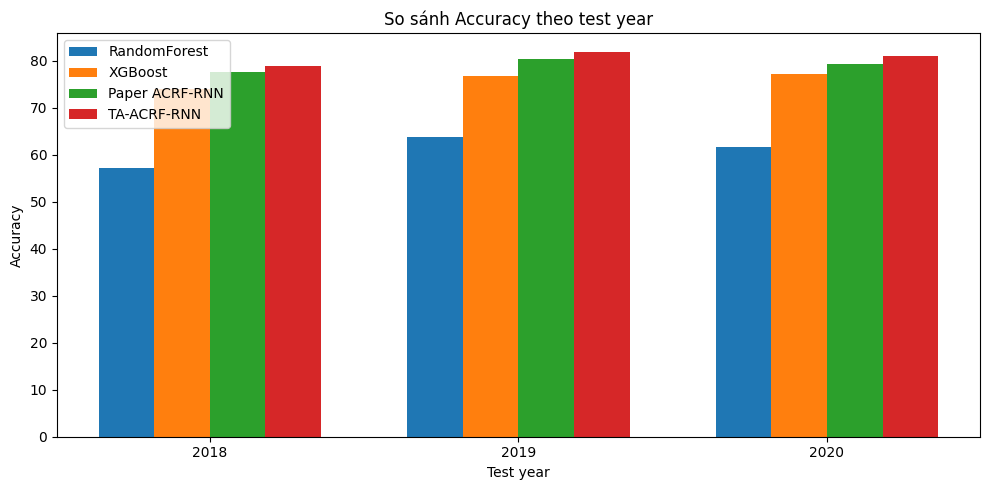

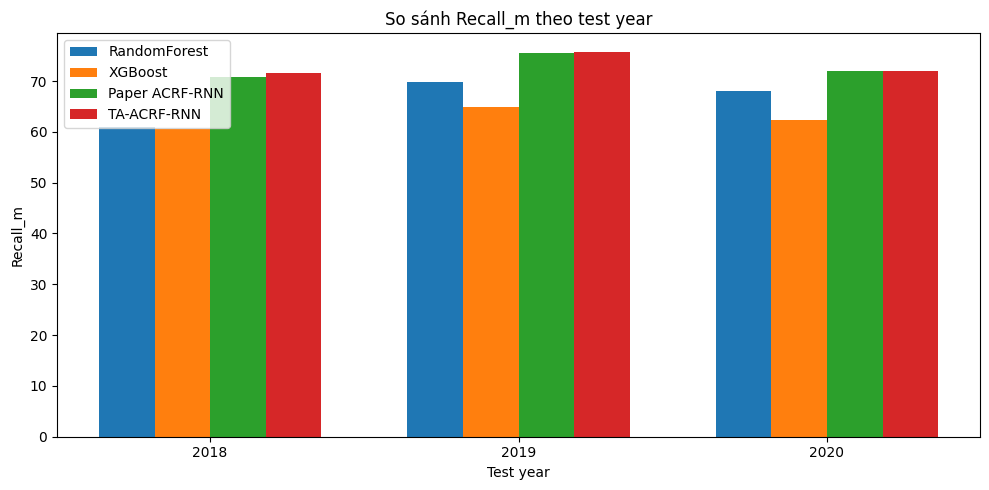

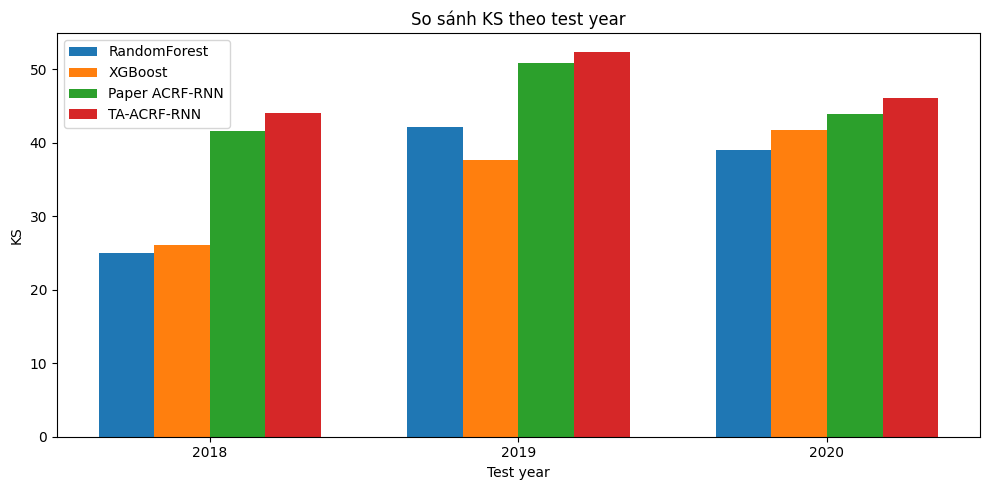

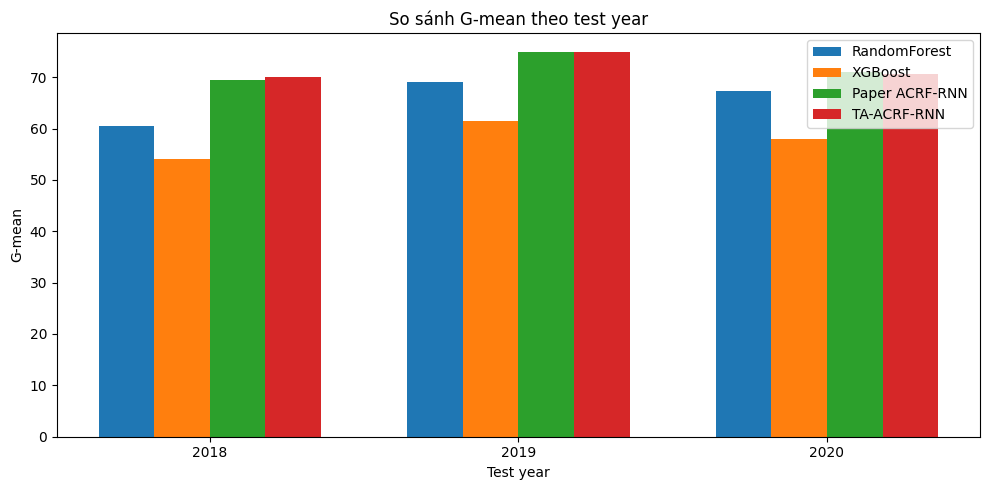

In [ ]:
# 10.1 So sánh từng metric theo từng test year

for metric in metric_cols:
    pivot_df = (
        compare_all_viz
        .pivot(index="test_year", columns="model", values=metric)
        .reindex(index=test_years_sorted, columns=model_order)
    )

    x = np.arange(len(pivot_df.index))
    width = 0.18

    plt.figure(figsize=(10, 5))
    for i, model in enumerate(model_order):
        if model in pivot_df.columns:
            plt.bar(x + (i - 1.5) * width, pivot_df[model], width, label=model)

    plt.xticks(x, pivot_df.index.astype(str))
    plt.xlabel("Test year")
    plt.ylabel(metric)
    plt.title(f"So sánh {metric} theo test year")
    plt.legend()
    plt.tight_layout()
    safe_metric = metric.replace("-", "_").replace("/", "_")
    plt.savefig(f"{FIG_DIR}/07_compare_{safe_metric}_by_test_year.png", dpi=200)
    plt.show()


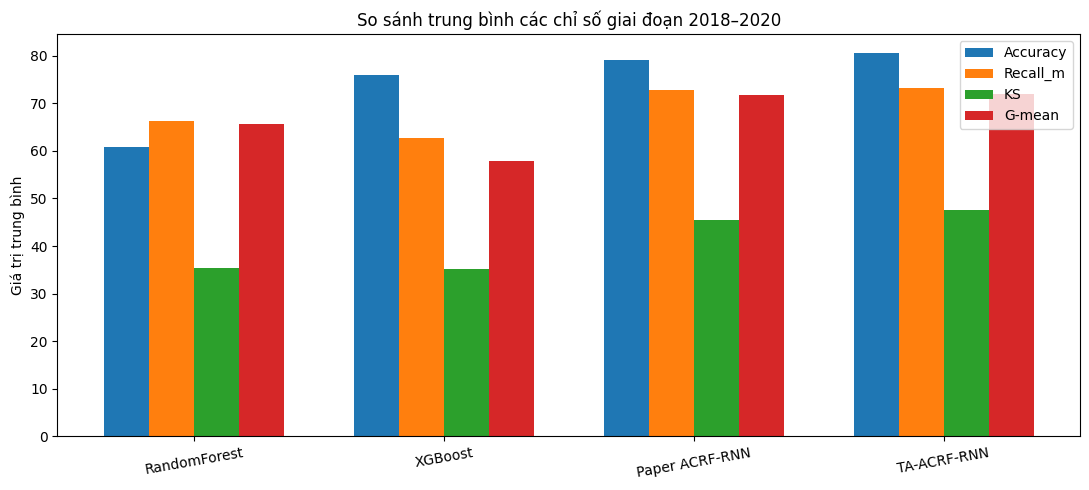

,Accuracy,Recall_m,KS,G-mean
model,,,,
RandomForest,60.90,66.28,35.42,65.59
XGBoost,75.97,62.66,35.14,57.80
Paper ACRF-RNN,79.16,72.73,45.46,71.77
TA-ACRF-RNN,80.58,73.12,47.50,71.87


In [ ]:
# 10.2 So sánh trung bình giai đoạn 2018–2020

avg_plot = avg_compare_viz.set_index("model").reindex(model_order)[metric_cols]

x = np.arange(len(avg_plot.index))
width = 0.18

plt.figure(figsize=(11, 5))
for i, metric in enumerate(metric_cols):
    plt.bar(x + (i - 1.5) * width, avg_plot[metric], width, label=metric)

plt.xticks(x, avg_plot.index, rotation=10)
plt.ylabel("Giá trị trung bình")
plt.title("So sánh trung bình các chỉ số giai đoạn 2018–2020")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_average_metric_comparison.png", dpi=200)
plt.show()

display(avg_plot.round(2))

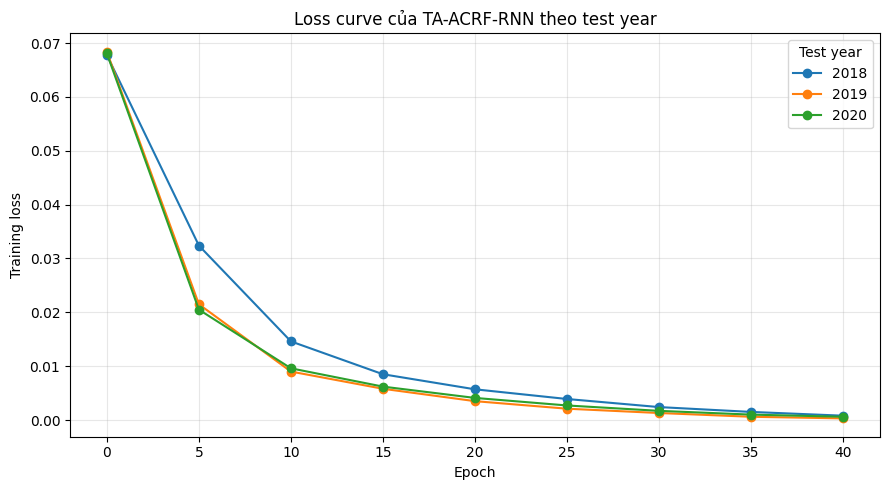

In [ ]:
# 10.3 Biểu đồ loss của TA-ACRF-RNN trong quá trình test

import re, os
loss_pat = re.compile(r"^\s*(\d{4})\s*\|\s*([\d.]+)\s*\|")

loss_rows = []
for year in [2018, 2019, 2020]:
    log_path = f"/content/project_outputs/run_ta_acrf_rnn_{year}.log"
    if not os.path.exists(log_path):
        continue

    with open(log_path, encoding="utf-8") as f:
        for line in f:
            m = loss_pat.search(line)
            if m:
                epoch, loss = m.groups()
                loss_rows.append({
                    "test_year": year,
                    "epoch": int(epoch),
                    "loss": float(loss)
                })

loss_df = pd.DataFrame(loss_rows)

if len(loss_df) == 0:
    print("Chưa tìm thấy log loss của TA-ACRF-RNN. Hãy chạy các cell test TA-ACRF-RNN trước.")
else:
    plt.figure(figsize=(9, 5))
    for name, g in loss_df.groupby("test_year"):
        plt.plot(g["epoch"], g["loss"], marker="o", label=str(name))
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("Loss curve của TA-ACRF-RNN theo test year")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Test year")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/09_ta_acrf_rnn_loss_curves.png", dpi=200)
    plt.show()


### 10.4 Tạo prediction để vẽ confusion matrix

Paper chỉ có kết quả tổng hợp trong bài báo, không có nhãn dự đoán từng doanh nghiệp, nên không thể vẽ confusion matrix cho Paper. Confusion matrix bên dưới được tạo cho 3 mô hình có thể sinh prediction trong notebook: Random Forest, XGBoost và TA-ACRF-RNN.

Các cột biểu đồ hiển thị trực tiếp theo test year 2018, 2019 và 2020.


In [ ]:
# 10.4.1 Tạo prediction cho Random Forest, XGBoost và TA-ACRF-RNN để vẽ confusion matrix

import os, sys, subprocess, textwrap

# Cài XGBoost nếu môi trường chưa có
try:
    import xgboost  # noqa: F401
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])

prediction_script = r"""
import os, json, random, warnings
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

DATA_PATH = "/content/project_data/processed_flat.json"
OUT_DIR = "/content/project_outputs"
SEED = 26541
np.random.seed(SEED)
random.seed(SEED)

def load_flat(path):
    with open(path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    years = [b["year"] for b in payload["data"]]
    rows = np.array([b["rows"] for b in payload["data"]], dtype=np.float32)
    X = rows[:, :, :-1]
    y = rows[:, :, -1].astype(int)
    return years, X, y

def make_xy(years, X, y, selected_years):
    idxs = [years.index(yy) for yy in selected_years]
    X_out = X[idxs].reshape(-1, X.shape[-1])
    y_out = y[idxs].reshape(-1)
    return X_out, y_out

def build_model(model_name, y_train):
    n_pos = max(int(np.sum(y_train == 1)), 1)
    n_neg = max(int(np.sum(y_train == 0)), 1)
    scale_pos_weight = n_neg / n_pos

    if model_name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=500,
            max_depth=8,
            min_samples_leaf=3,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1,
        )

    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=400,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            reg_alpha=0.1,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=SEED,
            n_jobs=-1,
            tree_method="hist",
        )
    raise ValueError(model_name)

def predict_prob_fraud(model, X_test):
    proba = model.predict_proba(X_test)
    if proba.shape[1] == 1:
        return np.zeros(len(X_test), dtype=float)
    return proba[:, 1]

def main():
    years, X, y = load_flat(DATA_PATH)

    tune_path = os.path.join(OUT_DIR, "baseline_rf_xgb_tune_2017.csv")
    if os.path.exists(tune_path):
        tune_df = pd.read_csv(tune_path)
        threshold_map = dict(zip(tune_df["model"], tune_df["best_threshold"]))
    else:
        threshold_map = {"RandomForest": 0.5, "XGBoost": 0.5}

    rows = []
    test_years = [2018, 2019, 2020]

    for model_name in ["RandomForest", "XGBoost"]:
        threshold = float(threshold_map.get(model_name, 0.5))

        for test_year in test_years:
            if test_year not in years:
                continue
            test_idx = years.index(test_year)
            train_years = years[:test_idx]

            X_train, y_train = make_xy(years, X, y, train_years)
            X_test, y_test = make_xy(years, X, y, [test_year])

            model = build_model(model_name, y_train)
            model.fit(X_train, y_train)
            prob = predict_prob_fraud(model, X_test)
            pred = (prob >= threshold).astype(int)

            for i in range(len(y_test)):
                rows.append({
                    "model": model_name,
                    "test_year": int(test_year),
                    "y_true": int(y_test[i]),
                    "y_pred": int(pred[i]),
                    "prob_fraud": float(prob[i]),
                })

    out_path = os.path.join(OUT_DIR, "predictions_rf_xgb_for_confusion.csv")
    pd.DataFrame(rows).to_csv(out_path, index=False)
    print(f"Saved {out_path}")

if __name__ == "__main__":
    main()
"""

with open("/content/ACRF-RNN/Code/main_tabular_predictions_for_viz.py", "w", encoding="utf-8") as f:
    f.write(prediction_script)

!python -m py_compile /content/ACRF-RNN/Code/main_tabular_predictions_for_viz.py
%cd /content/ACRF-RNN/Code
!python main_tabular_predictions_for_viz.py

/content/ACRF-RNN/Code
Saved /content/project_outputs/predictions_rf_xgb_for_confusion.csv


In [ ]:
# 10.4.2 Tạo prediction cho TA-ACRF-RNN để vẽ confusion matrix
# Cell này huấn luyện lại TA-ACRF-RNN với fixed_epoch=40 và fixed_threshold=0.68, sau đó lưu prediction từng mẫu.

ta_acrf_rnn_prediction_script = r"""
import os, json, random
import numpy as np
import pandas as pd
import torch
from torch import optim

from model_ta_acrf_rnn import *
from util4 import *

DATA_PATH = "/content/project_data/processed_flat.json"
OUT_DIR = "/content/project_outputs"

SEED = 26541
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

RNN_LEN = 3
FIXED_EPOCH = 40
FIXED_THRESHOLD = 0.68

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

def load_all(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    years = [b["year"] for b in payload["data"]]
    rows = [b["rows"] for b in payload["data"]]
    data = torch.from_numpy(np.array(rows, dtype=np.float32)).float()
    x = data[:, :, :-1]
    y = data[:, :, -1].unsqueeze(-1).long()
    return years, x, y

def build_blocks(years, x, y, test_year):
    test_idx = years.index(test_year)
    x_train = x[:test_idx]
    y_train = y[:test_idx]
    test_start = max(0, test_idx - RNN_LEN)
    x_eval = x[test_start:test_idx + 1]
    y_eval = y[test_start:test_idx + 1]
    return x_train, y_train, x_eval, y_eval

def do_train(model, x_train, y_train, optimizer, criterion):
    model.train()
    seq_len = len(x_train)
    train_seq = list(range(seq_len))[RNN_LEN:]
    if not train_seq:
        return

    random.shuffle(train_seq)
    optimizer.zero_grad()

    for step, i in enumerate(train_seq, start=1):
        x_i = x_train[i - RNN_LEN + 1:i + 1].to(DEVICE)
        y_i = y_train[i].to(DEVICE).view(-1).long()
        logits = model(x_i)
        loss = criterion(logits, y_i)
        loss.backward()

        if step % 4 == 0 or step == len(train_seq):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            optimizer.zero_grad()

def collect_predictions(model, x_block, y_block, test_year):
    model.eval()
    seq_len = len(x_block)
    seq = list(range(seq_len))[RNN_LEN:]

    rows = []
    with torch.no_grad():
        for i in seq:
            x_i = x_block[i - RNN_LEN + 1:i + 1].to(DEVICE)
            logits = model(x_i)
            prob = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            y_true = y_block[i].view(-1).detach().cpu().numpy().astype(int)
            y_pred = (prob >= FIXED_THRESHOLD).astype(int)

            for j in range(len(y_true)):
                rows.append({
                    "model": "TA-ACRF-RNN",
                    "test_year": int(test_year),
                    "y_true": int(y_true[j]),
                    "y_pred": int(y_pred[j]),
                    "prob_fraud": float(prob[j]),
                })
    return rows

def main():
    years, x, y = load_all(DATA_PATH)
    all_rows = []

    for test_pos, test_year in enumerate([2018, 2019, 2020], start=1):
        if test_year not in years:
            continue

        # Reset seed cho từng lần chạy để tái lập
        torch.manual_seed(SEED)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(SEED)
        np.random.seed(SEED)
        random.seed(SEED)

        x_train, y_train, x_eval, y_eval = build_blocks(years, x, y, test_year)
        num_company = x_train.size(1)
        d_feature = x_train.size(2)

        model = AC_RNN(
            num_company=num_company,
            d_feature=d_feature,
            d_hidden=d_feature,
            hidn_rnn=48,
            heads_att=3,
            hidn_att=24,
            crf_iters=3,
            alpha=0.5,
            pool_type="SUM",
            dropout=0.2,
            time_aware=True,
            temporal_lambdas=(0.7, 0.2, 0.1),
        ).to(DEVICE)

        class_weight = torch.tensor([0.10, 0.25]).float().to(DEVICE)
        criterion = FocalLoss(weight=class_weight, gamma=2.0)
        optimizer = optim.Adam(model.parameters(), lr=0.003)

        for epoch in range(FIXED_EPOCH + 1):
            do_train(model, x_train, y_train, optimizer, criterion)

        rows = collect_predictions(model, x_eval, y_eval, test_year)
        all_rows.extend(rows)

    out_path = os.path.join(OUT_DIR, "predictions_ta_acrf_rnn_for_confusion.csv")
    pd.DataFrame(all_rows).to_csv(out_path, index=False)
    print(f"Saved {out_path}")

if __name__ == "__main__":
    main()
"""

with open("/content/ACRF-RNN/Code/main_ta_acrf_rnn_predictions_for_viz.py", "w", encoding="utf-8") as f:
    f.write(ta_acrf_rnn_prediction_script)

!python -m py_compile /content/ACRF-RNN/Code/main_ta_acrf_rnn_predictions_for_viz.py
%cd /content/ACRF-RNN/Code
!python main_ta_acrf_rnn_predictions_for_viz.py

/content/ACRF-RNN/Code
Saved /content/project_outputs/predictions_ta_acrf_rnn_for_confusion.csv


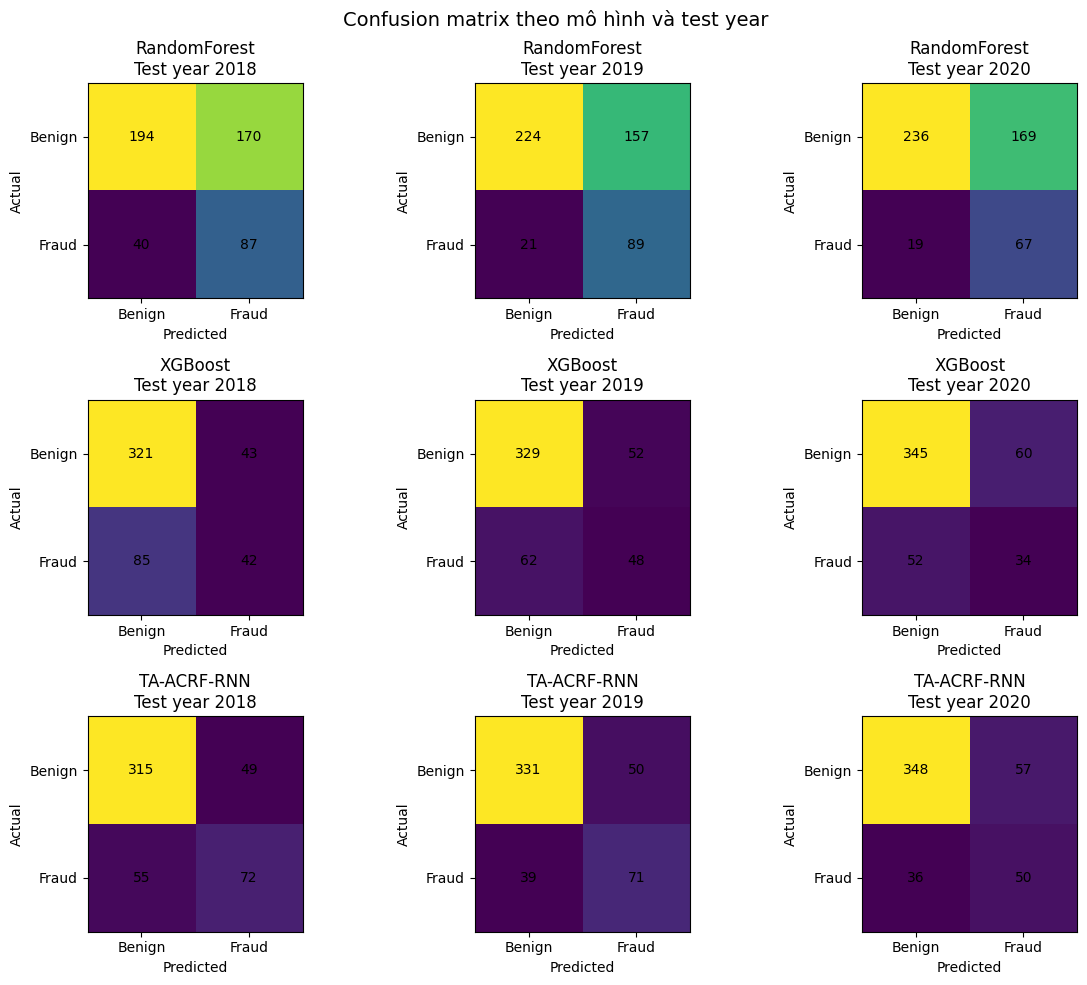

In [ ]:
# 10.4.3 Confusion matrix cho Random Forest, XGBoost và TA-ACRF-RNN

from sklearn.metrics import confusion_matrix

pred_paths = [
    "/content/project_outputs/predictions_rf_xgb_for_confusion.csv",
    "/content/project_outputs/predictions_ta_acrf_rnn_for_confusion.csv",
]

pred_dfs = [pd.read_csv(p) for p in pred_paths if os.path.exists(p)]
if len(pred_dfs) == 0:
    raise FileNotFoundError("Chưa có file prediction. Hãy chạy hai cell tạo prediction phía trên.")

pred_all = pd.concat(pred_dfs, ignore_index=True)

# Tương thích nếu còn file prediction cũ dùng cột test_alias.
if "test_year" not in pred_all.columns and "test_alias" in pred_all.columns:
    alias_map = {"Test set 1": 2018, "Test set 2": 2019, "Test set 3": 2020}
    pred_all["test_year"] = pred_all["test_alias"].map(alias_map)

pred_all.to_csv("/content/project_outputs/predictions_all_models_for_confusion.csv", index=False)

models_for_cm = ["RandomForest", "XGBoost", "TA-ACRF-RNN"]
tests_for_cm = [2018, 2019, 2020]

fig, axes = plt.subplots(len(models_for_cm), len(tests_for_cm), figsize=(12, 10))

for r, model_name in enumerate(models_for_cm):
    for c, test_year in enumerate(tests_for_cm):
        ax = axes[r, c]
        sub = pred_all[(pred_all["model"] == model_name) & (pred_all["test_year"] == test_year)]

        if len(sub) == 0:
            ax.axis("off")
            ax.set_title(f"{model_name}\n{test_year}")
            continue

        cm = confusion_matrix(sub["y_true"], sub["y_pred"], labels=[0, 1])
        im = ax.imshow(cm)

        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center")

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Benign", "Fraud"])
        ax.set_yticklabels(["Benign", "Fraud"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(f"{model_name}\nTest year {test_year}")

fig.suptitle("Confusion matrix theo mô hình và test year", fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_confusion_matrix_all_models_by_year.png", dpi=220)
plt.show()


,Year,Accuracy,Recall_m,KS,G-mean
0,2018,1.22,0.83,2.44,0.67
1,2019,1.42,0.27,1.45,-0.01
2,2020,1.63,0.07,2.22,-0.36


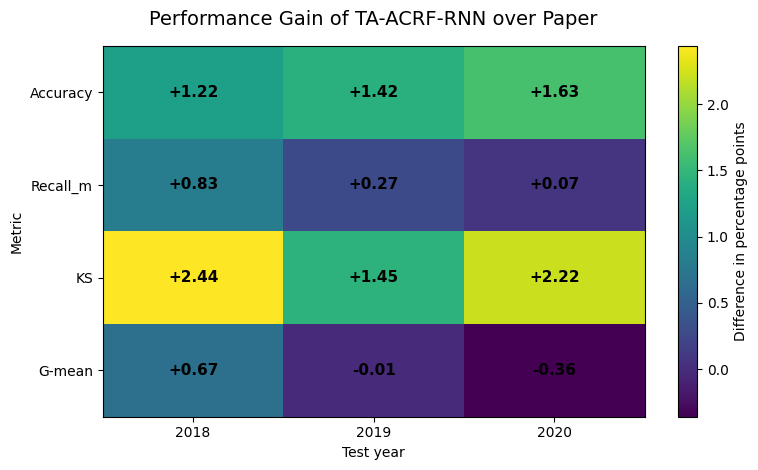

Đã lưu biểu đồ mức cải thiện tại: /content/project_outputs/ta_acrf_rnn_gain_over_paper.png


In [ ]:
# 10.5 Performance gain — Mức cải thiện của TA-ACRF-RNN so với Paper

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

by_year_path = "/content/project_outputs/compare_all_models_by_year.csv"

metric_cols = ["Accuracy", "Recall_m", "KS", "G-mean"]

PAPER = {
    2018: {"Accuracy": 77.60, "Recall_m": 70.79, "KS": 41.58, "G-mean": 69.37},
    2019: {"Accuracy": 80.45, "Recall_m": 75.44, "KS": 50.88, "G-mean": 74.89},
    2020: {"Accuracy": 79.43, "Recall_m": 71.96, "KS": 43.92, "G-mean": 71.04},
}

df = pd.read_csv(by_year_path)

# Chuẩn hóa tên cột model nếu cần
if "Model" not in df.columns:
    possible_model_cols = ["model", "Method", "method", "Mô hình", "Unnamed: 0"]
    found = next((c for c in possible_model_cols if c in df.columns), None)
    if found is None:
        raise KeyError(f"Không tìm thấy cột Model. Các cột hiện có: {list(df.columns)}")
    df = df.rename(columns={found: "Model"})

# Chuẩn hóa tên cột năm nếu cần
if "Year" not in df.columns:
    possible_year_cols = ["year", "TestYear", "test_year", "Test Year", "Năm"]
    found = next((c for c in possible_year_cols if c in df.columns), None)
    if found is not None:
        df = df.rename(columns={found: "Year"})
    else:
        raise KeyError(f"Không tìm thấy cột Year. Các cột hiện có: {list(df.columns)}")

# Chuẩn hóa tên model
df["Model"] = df["Model"].astype(str).replace({
    "VerA": "TA-ACRF-RNN",
    "VerA+": "TA-ACRF-RNN",
    "VerA IMPROVED": "TA-ACRF-RNN",
    "TA_ACRF_RNN": "TA-ACRF-RNN",
    "TA ACRF RNN": "TA-ACRF-RNN",
})

# Chỉ lấy TA-ACRF-RNN
ta_df = df[df["Model"] == "TA-ACRF-RNN"].copy()

if ta_df.empty:
    raise ValueError("Không tìm thấy dòng model TA-ACRF-RNN trong compare_all_models_by_year.csv")

# Đảm bảo metric là dạng %
for col in metric_cols:
    ta_df[col] = pd.to_numeric(ta_df[col], errors="coerce")
    if ta_df[col].max() <= 1.5:
        ta_df[col] = ta_df[col] * 100

ta_df["Year"] = ta_df["Year"].astype(int)

# Tính chênh lệch TA-ACRF-RNN - Paper
gain_rows = []

for _, row in ta_df.iterrows():
    year = int(row["Year"])
    if year not in PAPER:
        continue

    out = {"Year": year}
    for metric in metric_cols:
        out[metric] = row[metric] - PAPER[year][metric]
    gain_rows.append(out)

gain_df = pd.DataFrame(gain_rows).sort_values("Year")

display(gain_df)

# Pivot: hàng là metric, cột là năm
gain_matrix = gain_df.set_index("Year")[metric_cols].T

fig, ax = plt.subplots(figsize=(8, 4.8))

im = ax.imshow(gain_matrix.values, aspect="auto")

ax.set_xticks(np.arange(len(gain_matrix.columns)))
ax.set_xticklabels(gain_matrix.columns)

ax.set_yticks(np.arange(len(gain_matrix.index)))
ax.set_yticklabels(gain_matrix.index)

# Ghi giá trị chênh lệch vào từng ô
for i in range(gain_matrix.shape[0]):
    for j in range(gain_matrix.shape[1]):
        value = gain_matrix.iloc[i, j]
        sign = "+" if value >= 0 else ""
        ax.text(
            j, i,
            f"{sign}{value:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

ax.set_title("Performance Gain of TA-ACRF-RNN over Paper", fontsize=14, pad=15)
ax.set_xlabel("Test year")
ax.set_ylabel("Metric")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Difference in percentage points")

plt.tight_layout()

out_path = "/content/project_outputs/ta_acrf_rnn_gain_over_paper.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Đã lưu biểu đồ mức cải thiện tại: {out_path}")

### Nhận xét kết quả so sánh

Kết quả thực nghiệm cho thấy **TA-ACRF-RNN** là mô hình có hiệu quả tổng thể tốt nhất trong nhóm mô hình được so sánh. Mô hình này không chỉ kế thừa hướng tiếp cận học quan hệ giữa các doanh nghiệp của ACRF-RNN, mà còn được điều chỉnh theo hướng phù hợp hơn với dữ liệu tài chính theo thời gian: chuẩn hóa attention bằng softmax, huấn luyện bằng logits thay vì đưa softmax trực tiếp vào hàm mất mát, bổ sung cơ chế **time-aware relation** để kết hợp thông tin quan hệ ở các giai đoạn gần nhau, đồng thời sử dụng threshold được tune trên tập validation và cố định khi kiểm thử. Cách làm này giúp mô hình hạn chế việc chọn tham số trực tiếp trên tập test và tăng độ tin cậy của kết quả so sánh.

So với **Paper ACRF-RNN**, TA-ACRF-RNN cho thấy mức cải thiện rõ nhất ở các chỉ số **Accuracy** và **KS** trên các năm kiểm thử. Trong bối cảnh phát hiện gian lận tài chính, KS là chỉ số rất quan trọng vì nó phản ánh khả năng tách biệt giữa nhóm doanh nghiệp gian lận và không gian lận. Việc KS tăng cho thấy mô hình cải tiến có khả năng xếp hạng rủi ro tốt hơn, hỗ trợ phát hiện các trường hợp gian lận tiềm ẩn hiệu quả hơn. Bên cạnh đó, Recall_m được duy trì ở mức cao, cho thấy mô hình không chỉ tối ưu độ chính xác tổng thể mà còn quan tâm đến khả năng nhận diện lớp gian lận trong điều kiện dữ liệu mất cân bằng. Chỉ số G-mean nhìn chung ở mức xấp xỉ Paper, cho thấy mô hình vẫn giữ được sự cân bằng tương đối giữa hai lớp.

So với **Random Forest**, TA-ACRF-RNN vượt trội hơn vì Random Forest chỉ khai thác dữ liệu dưới dạng bảng tại từng mẫu riêng lẻ. Mặc dù Random Forest là một baseline truyền thống ổn định và dễ diễn giải, mô hình này không học được chuỗi biến động tài chính qua nhiều năm và cũng không khai thác quan hệ tiềm ẩn giữa các doanh nghiệp. Do đó, Random Forest thường gặp hạn chế ở các chỉ số phản ánh năng lực phân biệt rủi ro như KS và G-mean. Kết quả này cho thấy đối với dữ liệu tài chính có yếu tố thời gian, việc chỉ dựa vào mô hình học máy truyền thống là chưa đủ để nắm bắt đầy đủ hành vi gian lận.

So với **XGBoost**, TA-ACRF-RNN vẫn cho kết quả tốt hơn về tổng thể. XGBoost là một baseline mạnh cho dữ liệu dạng bảng và thường hoạt động tốt trong các bài toán rủi ro tài chính, tín dụng và phát hiện bất thường. Tuy nhiên, XGBoost chủ yếu học quan hệ phi tuyến giữa các đặc trưng đã được làm phẳng, chưa trực tiếp mô hình hóa sự thay đổi theo thời gian và mối liên hệ động giữa các doanh nghiệp. Trong khi đó, TA-ACRF-RNN tận dụng đồng thời ba nguồn thông tin: đặc trưng tài chính, chuỗi thời gian và quan hệ giữa các công ty. Đây là lý do mô hình cải tiến đạt kết quả nổi bật hơn, đặc biệt ở các chỉ số đánh giá khả năng phân biệt gian lận.

Từ góc nhìn tài chính, bài toán phát hiện gian lận thường có hai đặc điểm quan trọng: dữ liệu mất cân bằng và hành vi gian lận thay đổi theo thời gian. Nếu chỉ dùng Accuracy, mô hình có thể bị đánh giá sai vì lớp không gian lận chiếm tỷ lệ lớn hơn. Vì vậy, việc kết hợp **Recall_m, KS và G-mean** là cần thiết để đánh giá toàn diện hơn. Kết quả thực nghiệm cho thấy TA-ACRF-RNN phù hợp với bối cảnh này vì mô hình không chỉ cải thiện độ chính xác, mà còn nâng cao khả năng phân biệt nhóm rủi ro và duy trì hiệu quả trên nhiều năm kiểm thử.

Tóm lại, kết quả so sánh giữa Paper, Random Forest, XGBoost và TA-ACRF-RNN cho thấy mô hình cải tiến có ưu thế rõ ràng nhờ khai thác được đặc trưng theo thời gian và quan hệ giữa các doanh nghiệp. Điều này chứng minh rằng trong bài toán phát hiện gian lận tài chính, các mô hình tabular truyền thống như Random Forest và XGBoost là baseline cần thiết, nhưng chưa đủ để thay thế các mô hình có khả năng học quan hệ động theo thời gian như TA-ACRF-RNN.

## Giai đoạn 11 — Lưu kết quả


In [ ]:
os.makedirs("/content/project_outputs", exist_ok=True)

if "compare_all" in globals():
    compare_all.to_csv("/content/project_outputs/compare_all_models_by_year.csv", index=False)

if "avg_compare" in globals():
    avg_compare.to_csv("/content/project_outputs/compare_all_models_average.csv", index=False)

if "baseline_df" in globals():
    baseline_df.to_csv("/content/project_outputs/baseline_rf_xgb_results.csv", index=False)

print("Đã lưu kết quả so sánh Paper, Random Forest, XGBoost và TA-ACRF-RNN")
!ls -lh /content/project_outputs/


Đã lưu kết quả so sánh Paper, Random Forest, XGBoost và TA-ACRF-RNN
total 400K
-rw-r--r-- 1 root root 1.1K Jun  3 15:19 baseline_rf_xgb_results.csv
-rw-r--r-- 1 root root  310 Jun  3 15:18 baseline_rf_xgb_tune_2017.csv
drwxr-xr-x 2 root root 4.0K Jun  3 15:15 checkpoints_ta_acrf_rnn
-rw-r--r-- 1 root root  175 Jun  3 15:19 compare_all_models_average.csv
-rw-r--r-- 1 root root  845 Jun  3 15:19 compare_all_models_by_year.csv
drwxr-xr-x 2 root root 4.0K Jun  3 15:19 figures
-rw-r--r-- 1 root root 168K Jun  3 15:19 predictions_all_models_for_confusion.csv
-rw-r--r-- 1 root root 112K Jun  3 15:19 predictions_rf_xgb_for_confusion.csv
-rw-r--r-- 1 root root  59K Jun  3 15:19 predictions_ta_acrf_rnn_for_confusion.csv
-rw-r--r-- 1 root root 2.6K Jun  3 15:18 run_baseline_rf_xgb.log
-rw-r--r-- 1 root root 2.4K Jun  3 15:16 run_ta_acrf_rnn_2018.log
-rw-r--r-- 1 root root 2.4K Jun  3 15:16 run_ta_acrf_rnn_2019.log
-rw-r--r-- 1 root root 2.4K Jun  3 15:16 run_ta_acrf_rnn_2020.log
-rw-r--r-- 1 root

## Giai đoạn 12 — Nén output và lưu về Google Drive


In [ ]:
!zip -r /content/project_outputs/ta_acrf_rnn_baseline_comparison_outputs.zip /content/project_outputs/
!ls -lh /content/project_outputs/ta_acrf_rnn_baseline_comparison_outputs.zip

import shutil, os

drive_save_path = '/content/drive/MyDrive/ACRF-RNN'
os.makedirs(drive_save_path, exist_ok=True)
shutil.copy('/content/project_outputs/ta_acrf_rnn_baseline_comparison_outputs.zip',
            f'{drive_save_path}/ta_acrf_rnn_baseline_comparison_outputs.zip')
print(f'Đã lưu vào Drive: {drive_save_path}/ta_acrf_rnn_baseline_comparison_outputs.zip')


  adding: content/project_outputs/ (stored 0%)
  adding: content/project_outputs/run_ta_acrf_rnn_2018.log (deflated 65%)
  adding: content/project_outputs/predictions_all_models_for_confusion.csv (deflated 73%)
  adding: content/project_outputs/predictions_rf_xgb_for_confusion.csv (deflated 73%)
  adding: content/project_outputs/xgboost_top15_feature_importance.csv (deflated 46%)
  adding: content/project_outputs/run_baseline_rf_xgb.log (deflated 73%)
  adding: content/project_outputs/baseline_rf_xgb_tune_2017.csv (deflated 36%)
  adding: content/project_outputs/time_alias_mapping_private.csv (deflated 25%)
  adding: content/project_outputs/figures/ (stored 0%)
  adding: content/project_outputs/figures/10_confusion_matrix_all_models_by_year.png (deflated 20%)
  adding: content/project_outputs/figures/05_tsne_projection.png (deflated 4%)
  adding: content/project_outputs/figures/08_average_metric_comparison.png (deflated 19%)
  adding: content/project_outputs/figures/01_label_distributi